# Mon Sandbox

Notebook pour tester du script afin d'alimenter la base de données :p

### test sur inaturalist

In [ ]:
import requests
import json

# URL de l'API iNaturalist
url = "https://api.inaturalist.org/v1/observations"

# Paramètres mis à jour
params = {
    "taxon_id": "47219,52747",  
    "per_page": 10,              
    "page": 1                 
}


response = requests.get(url, params=params)


if response.status_code == 200:
    data = response.json()
    observations = data.get("results", [])

    # test sur 3 results, afin d'observer la structure
    print(json.dumps(observations[:3], indent=4, ensure_ascii=False))

else:
    print(f"Erreur {response.status_code}: Impossible d’accéder aux observations.")


In [ ]:
import requests

# URL de l'API iNaturalist
url = "https://api.inaturalist.org/v1/observations"

# Paramètres mis à jour
# taxon : # Apidae (abeilles) et Vespidae (frelons)
params = {
    "taxon_id": "47219,52747",  
    "per_page": 10,              
    "page": 1                    
}

# Effectuer la requête
response = requests.get(url, params=params)


if response.status_code == 200:
    data = response.json()
    observations = data.get("results", [])

  
    if not observations:
        print("Aucune observation trouvée avec ces paramètres.")
    else:
        # Afficher les résultats
        for obs in observations:
            id_obs = obs.get("id", "Inconnu")
            nom = obs.get("species_guess", "Nom inconnu")
            date = obs.get("observed_on", "Date inconnue")
            latitude = obs.get("latitude", "Inconnue")
            longitude = obs.get("longitude", "Inconnue")
            lien = f"https://www.inaturalist.org/observations/{id_obs}"

            print(f"ID: {id_obs}, Nom: {nom}, Date: {date}, Lien: {lien}, Localisation: ({latitude}, {longitude})")

else:
    print(f"Erreur {response.status_code}: Impossible d’accéder aux observations.")


In [ ]:
import requests
import json

# URL de l'API iNaturalist
url = "https://api.inaturalist.org/v1/observations"

# Paramètres de la requête API
params = {
    "taxon_id": "47219,52747",  # Apidae (abeilles) et Vespidae (frelons)
    "per_page": 10,              # Nombre d'observations par page
    "page": 1,                   # Première page des résultats
    "order_by": "observed_on",    # Trier par date d'observation
}

# Effectuer la requête
response = requests.get(url, params=params)

# Vérifier si la requête a réussi
if response.status_code == 200:
    data = response.json()
    observations = data.get("results", [])

    # Vérifier si des résultats existent
    if not observations:
        print("Aucune observation trouvée avec ces paramètres.")
    else:
        # Afficher les résultats
        for obs in observations:
            id_obs = obs.get("id", "Inconnu")
            nom = obs.get("species_guess", "Nom inconnu")
            date = obs.get("observed_on", "Date inconnue")
            latitude = obs.get("latitude", "Inconnue")
            longitude = obs.get("longitude", "Inconnue")
            place = obs.get("place_guess", "Lieu inconnu")
            user = obs.get("user", {}).get("login", "Utilisateur inconnu")
            image = obs.get("photos", [{}])[0].get("url", "Aucune image")
            quality = obs.get("quality_grade", "Inconnu")  # 'research', 'needs_id', 'casual'
            identifications = obs.get("identifications_count", 0)  # Nombre de vérifications par d'autres utilisateurs
            lien = f"https://www.inaturalist.org/observations/{id_obs}"

            # Affichage structuré
            print(f"🔹 **Observation ID:** {id_obs}")
            print(f"👤 **Utilisateur:** {user}")
            print(f"📅 **Date:** {date}")
            print(f"📍 **Lieu:** {place}")
            print(f"🌍 **Coordonnées:** ({latitude}, {longitude})")
            print(f"📸 **Image:** {image}")
            print(f"🔍 **Qualité des données:** {quality}")
            print(f"📊 **Nombre d'identifications:** {identifications}")
            print(f"🔗 **Lien:** {lien}")
            print("-" * 80)

else:
    print(f"Erreur {response.status_code}: Impossible d’accéder aux observations.")


#### Remarque

Aucune données localisation précise au sein de l'api > pour y remédier passer par les liens d'observations

Abeilles :

Abeille domestique (Apis mellifera) : 47218

Famille des Apidés (incluant de nombreuses espèces d'abeilles) : 47219


Guêpes :


Famille des Vespidés (incluant de nombreuses espèces de guêpes) : 52747


Frelons :

Frelon asiatique (Vespa velutina) : 52750

Frelon européen (Vespa crabro) : 52749

In [ ]:
import requests
import json
import datetime
import time
import os

# URL de l'API iNaturalist
url = "https://api.inaturalist.org/v1/observations"

# Définir les taxons (abeilles, guêpes, frelons, ruches)
taxon_ids = "630955,630956,538877,538878,52747,47218"  

# Définir une date de départ
d1 = "2014-01-01"  

# Fichiers pour sauvegarder les données
OBSERVATIONS_FILE = "observations.json"
EXTRACTED_FILE = "extracted_data_v3.json"

# Charger les observations précédemment enregistrées si le fichier existe
if os.path.exists(OBSERVATIONS_FILE):
    with open(OBSERVATIONS_FILE, "r", encoding="utf-8") as f:
        all_observations = json.load(f)
        print(f"📂 Chargement de {len(all_observations)} observations depuis {OBSERVATIONS_FILE}.")
else:
    all_observations = []

page = (len(all_observations) // 100) + 1  # Déterminer la page où continuer

while True:
    print(f"🔄 Récupération de la page {page}...")

    # Paramètres de la requête
    params = {
        "taxon_id": taxon_ids,  # Abeilles, guêpes, frelons, ruches
        "per_page": 100,  # Maximiser à 100 pour optimiser les requêtes
        "page": page,  # Pagination
        "order_by": "observed_on",  # Trier par date d'observation
        "order": "asc",  # Chronologique
        "d1": d1,  # Date de début
        "geoprivacy": "open",  # Données ouvertes
        "place_id": 6753  # Modifier selon la région
    }

    # Requête API
    response = requests.get(url, params=params)

    # Vérifier si la requête est un succès
    if response.status_code == 200:
        data = response.json()
        observations = data.get("results", [])

        if not observations:
            print("✅ Fin de récupération (plus d'observations à récupérer).")
            break  # Arrêter si plus de résultats

        # Ajouter les observations à la liste
        all_observations.extend(observations)
        print(f"📊 {len(all_observations)} observations récupérées.")

        # Sauvegarder les observations après chaque requête
        with open(OBSERVATIONS_FILE, "w", encoding="utf-8") as f:
            json.dump(all_observations, f, ensure_ascii=False, indent=4)
            print(f"💾 Données sauvegardées dans {OBSERVATIONS_FILE}.")

        page += 1  # Passer à la page suivante

        # Petite pause pour éviter le rate limit de l'API
        time.sleep(1)

    else:
        print(f"❌ Erreur {response.status_code}: Impossible de récupérer les données.")
        break  # Arrêter en cas d'erreur

# 🔹 Trier les observations en ordre chronologique (normalement déjà triées)
all_observations.sort(key=lambda x: x.get("observed_on", "9999-12-31"))

# Charger les données extraites précédemment enregistrées
if os.path.exists(EXTRACTED_FILE):
    with open(EXTRACTED_FILE, "r", encoding="utf-8") as f:
        extracted_data = json.load(f)
        print(f"📂 Chargement de {len(extracted_data)} extractions depuis {EXTRACTED_FILE}.")
else:
    extracted_data = []

# 🔹 **Extraction des données**
for i, obs in enumerate(all_observations):

    id_obs = obs.get("id", "Unknown")
    date = obs.get("observed_on", "Unknown Date")
    place = obs.get("place_guess", "Unknown Place")

    # Extract Taxon Data
    taxon = obs.get("taxon", {})
    scientific_name = taxon.get("name", "Unknown Scientific Name")
    common_name = taxon.get("preferred_common_name", "Unknown Common Name")
    observation_link = obs.get("uri", f"https://www.inaturalist.org/observations/{id_obs}")

    # Stocker dans extracted_data
    extracted_data.append({
        "ID": id_obs,
        "Scientific Name": scientific_name,
        "Common Name": common_name,
        "Date": date,
        "Place": place,
        "Observation Link": observation_link
    })

    # Sauvegarder après chaque 200 extractions (optimisation des écritures disque)


In [50]:
import requests
import json
import datetime
import time
import os

# URL de l'API iNaturalist
url = "https://api.inaturalist.org/v1/observations"

# Définir les taxons (abeilles, guêpes, frelons, ruches)
taxon_ids = "630955,630956,538877,538878,52747,47218"  

# Définir une date de départ
d1 = "2024-01-01"  

OBSERVATIONS_FILE = os.path.join(os.getcwd(), "observations_2023_2025.json")
EXTRACTED_FILE = os.path.join(os.getcwd(), "extracted_data_2023_2025.json")

# Charger les observations précédemment enregistrées si le fichier existe
if os.path.exists(OBSERVATIONS_FILE):
    with open(OBSERVATIONS_FILE, "r", encoding="utf-8") as f:
        all_observations = json.load(f)
        print(f"📂 Chargement de {len(all_observations)} observations depuis {OBSERVATIONS_FILE}.")
else:
    all_observations = []

page = (len(all_observations) // 100) + 1  # Déterminer la page où continuer

while True:
    print(f"🔄 Récupération de la page {page}...")

    # Paramètres de la requête
    params = {
        "taxon_id": taxon_ids,
        "per_page": 100,  
        "page": page,  
        "order_by": "observed_on",
        "order": "asc",  
        "d1": d1,  
        "geoprivacy": "open",
        "place_id": 6753  
    }

    # Requête API
    response = requests.get(url, params=params)

    # Vérifier si la requête est un succès
    if response.status_code == 200:
        data = response.json()
        observations = data.get("results", [])

        if not observations:
            print("✅ Fin de récupération (plus d'observations à récupérer).")
            break  

        # Ajouter les observations à la liste
        all_observations.extend(observations)
        print(f"📊 {len(all_observations)} observations récupérées.")
        # Sauvegarder les observations après chaque requête
        with open(OBSERVATIONS_FILE, "w", encoding="utf-8") as f:
            json.dump(all_observations, f, ensure_ascii=False, indent=4)
            print(f"💾 Données sauvegardées dans {OBSERVATIONS_FILE}.")

        page += 1  

        # Petite pause pour éviter le rate limit de l'API
        time.sleep(1)

    else:
        print(f"❌ Erreur {response.status_code}: Impossible de récupérer les données.")
        break  

# 🔹 Trier les observations en ordre chronologique
all_observations.sort(key=lambda x: x.get("observed_on", "9999-12-31"))

# Charger les données extraites précédemment enregistrées
if os.path.exists(EXTRACTED_FILE):
    with open(EXTRACTED_FILE, "r", encoding="utf-8") as f:
        extracted_data = json.load(f)
        print(f"📂 Chargement de {len(extracted_data)} extractions depuis {EXTRACTED_FILE}.")
else:
    extracted_data = []

# 🔹 **Extraction des données**
for i, obs in enumerate(all_observations):

    id_obs = obs.get("id", "Unknown")
    date = obs.get("observed_on", "Unknown Date")
    time_zone = obs.get("observed_time_zone", "Unknown Timezone")
    positional_accuracy = obs.get("positional_accuracy", "Unknown")
    public_accuracy = obs.get("public_positional_accuracy", "Unknown")
    geoprivacy = obs.get("geoprivacy", "Unknown")
    quality_grade = obs.get("quality_grade", "Unknown") 
    identifications_count = obs.get("identifications_count", 0)
    num_agreements = obs.get("num_identification_agreements", 0)
    num_disagreements = obs.get("num_identification_disagreements", 0)

    # 🔹 **Extract Coordinates**
    longitude, latitude = None, None
    geojson = obs.get("geojson")
    if geojson and isinstance(geojson, dict) and "coordinates" in geojson:
        coordinates = geojson["coordinates"]
        if isinstance(coordinates, list) and len(coordinates) == 2:
            longitude, latitude = coordinates  

    if not longitude or not latitude:
        location = obs.get("location")
        if location and isinstance(location, str):
            try:
                lat, lon = map(float, location.split(","))
                latitude, longitude = lat, lon
            except ValueError:
                pass  

    # Extract place information
    place = obs.get("place_guess", "Unknown Place")

    # Extract Taxon Data
    taxon = obs.get("taxon", {})
    scientific_name = taxon.get("name", "Unknown Scientific Name")
    common_name = taxon.get("preferred_common_name", "Unknown Common Name")
    taxon_rank = taxon.get("rank", "Unknown Rank")
    taxon_id = taxon.get("id", "Unknown")
    wiki_url = taxon.get("wikipedia_url", "No Wikipedia Link")

    # Extract User Data
    user = obs.get("user", {})
    user_login = user.get("login", "Unknown User")
    user_observations = user.get("observations_count", 0)
    user_identifications = user.get("identifications_count", 0)
    user_icon = user.get("icon_url", "No User Image")

    # Extract Media
    photos = obs.get("photos", [])
    image_url = photos[0]["url"] if photos else "No Image"

    # Extract Annotations, Comments, and Tags
    annotations = [a.get("concatenated_attr_val", "No Annotation") for a in obs.get("annotations", [])]
    comments = obs.get("comments_count", 0)
    tags = ", ".join(obs.get("tags", ["No Tags"]))

    # Extract Extra Metadata
    uuid = obs.get("uuid", "Unknown")
    description = obs.get("description", "No Description")
    votes = obs.get("cached_votes_total", 0)
    observation_link = obs.get("uri", f"https://www.inaturalist.org/observations/{id_obs}")

    # Stocker dans extracted_data
    extracted_data.append({
        "ID": id_obs,
        "Scientific Name": scientific_name,
        "Common Name": common_name,
        "Taxon Rank": taxon_rank,
        "Taxon ID": taxon_id,
        "Wikipedia Link": wiki_url,
        "User": user_login,
        "User Observations": user_observations,
        "User Identifications": user_identifications,
        "User Icon": user_icon,
        "Date": date,
        "Time Zone": time_zone,
        "Latitude": latitude,
        "Longitude": longitude,
        "Place": place,
        "Positional Accuracy": positional_accuracy,
        "Public Accuracy": public_accuracy,
        "Geoprivacy": geoprivacy,
        "Quality Grade": quality_grade,
        "Identifications Count": identifications_count,
        "Agreements": num_agreements,
        "Disagreements": num_disagreements,
        "Image": image_url,
        "Annotations": annotations,
        "Comments Count": comments,
        "Tags": tags,
        "Votes": votes,
        "UUID": uuid,
        "Description": description,
        "Observation Link": observation_link
    })

# Sauvegarde finale
with open(EXTRACTED_FILE, "w", encoding="utf-8") as f:
    json.dump(extracted_data, f, ensure_ascii=False, indent=4)
    print(f"✅ Extraction complète. Total: {len(extracted_data)} observations extraites sauvegardées.")



📂 Chargement de 10000 observations depuis c:\Users\Yann\Desktop\DEV\stages\Abeille\daen-analytics\scrappers\observations_2023_2025.json.
🔄 Récupération de la page 101...
❌ Erreur 403: Impossible de récupérer les données.
📂 Chargement de 10000 extractions depuis c:\Users\Yann\Desktop\DEV\stages\Abeille\daen-analytics\scrappers\extracted_data_2023_2025.json.
✅ Extraction complète. Total: 20000 observations extraites sauvegardées.


## test sur v2

In [ ]:
import requests
import json
import time
import os

# 📌 URL de l'API iNaturalist v2
url = "https://api.inaturalist.org/v2/observations"

# 📌 Définir les taxons (abeilles, guêpes, frelons, ruches)
taxon_ids = [630955, 630956, 538877, 538878, 52747, 47218]  

# 📌 Définir une date de départ
d1 = "2023-01-01"
place_id_france = 6753  # ID France pour iNaturalist

# 📂 Fichiers de sauvegarde
OBSERVATIONS_FILE = os.path.join(os.getcwd(), "observations_2023_2025_v4.json")
EXTRACTED_FILE = os.path.join(os.getcwd(), "extracted_data_2023_2025_v4.json")

# 📂 Charger les observations précédemment enregistrées
if os.path.exists(OBSERVATIONS_FILE):
    with open(OBSERVATIONS_FILE, "r", encoding="utf-8") as f:
        all_observations = json.load(f)
        print(f"📂 Chargement de {len(all_observations)} observations depuis {OBSERVATIONS_FILE}.")
else:
    all_observations = []

page = (len(all_observations) // 100) + 1  # 📌 Déterminer la page où continuer

while True:
    # print(f"🔄 Récupération de la page {page}...")

    # 📌 Paramètres de la requête pour l'API v2
    params = {
        "taxon_ids": taxon_ids,   
        "per_page": 100,  
        "page": page,  
        "order_by": "observed_on",
        "order": "asc", # asc ou desc 
        "d1": d1,  
        "geoprivacy": "open",
        "place_id": place_id_france,  # On récupère toutes les observations en France
        "fields": ",".join([
            "id", "uuid", "observed_on", "observed_time_zone", "positional_accuracy",
            "public_positional_accuracy", "geoprivacy", "quality_grade",
            "identifications_count", "num_identification_agreements",
            "num_identification_disagreements", "geojson", "location",
            "place_guess", "taxon", "user", "photos", "annotations",
            "comments_count", "tags", "cached_votes_total", "description",
            "project_ids", "sounds", "created_at", "updated_at",
            "obscured", "place_ids", "identifications", "observations",
            "outlinks", "faves_count", "observation_photos",

            # 📌 Champs détaillés du taxon
            "taxon.id", "taxon.name", "taxon.rank", "taxon.preferred_common_name",
            "taxon.wikipedia_url", "taxon.default_photo.url", "taxon.default_photo.attribution",
            "taxon.default_photo.license_code", "taxon.iconic_taxon_name",
            "taxon.ancestor_ids", "taxon.conservation_status",

            # 📌 Champs détaillés du user
            "user.id", "user.login", "user.name", "user.icon_url", "user.roles", "user.created_at",

            # 📌 Champs détaillés des photos
            "photos.id", "photos.url", "photos.attribution", "photos.license_code"
        ])
    }

    # 📌 Requête API
    response = requests.get(url, params=params)

    if response.status_code == 200:
        data = response.json()
        observations = data.get("results", [])

        if not observations:
            # print("✅ Fin de récupération (plus d'observations à récupérer).")
            break  

        # 📌 Ajouter les observations à la liste
        all_observations.extend(observations)
        # print(f"📊 {len(all_observations)} observations récupérées.")

        # 💾 Sauvegarde intermédiaire
        with open(OBSERVATIONS_FILE, "w", encoding="utf-8") as f:
            json.dump(all_observations, f, ensure_ascii=False, indent=4)
        if page % 10 == 0:
             print(f"💾 Données sauvegardées dans {OBSERVATIONS_FILE} (page {page}).")

        page += 1  
        time.sleep(1)  # Pause pour éviter le rate limit

    else:
        print(f"❌ Erreur {response.status_code}: Impossible de récupérer les données.")
        break  

# 🔹 Trier les observations en ordre chronologique
all_observations.sort(key=lambda x: x.get("observed_on", "9999-12-31"))

# 📂 Charger les données extraites précédemment enregistrées 
if os.path.exists(EXTRACTED_FILE):
    with open(EXTRACTED_FILE, "r", encoding="utf-8") as f:
        extracted_data = json.load(f)
        # print(f"📂 Chargement de {len(extracted_data)} extractions depuis {EXTRACTED_FILE}.")
else:
    extracted_data = []

# 🔹 **Filtrage manuel des observations en France**
for obs in all_observations:
    longitude, latitude = None, None
    geojson = obs.get("geojson", {})
    if geojson.get("coordinates"):
        longitude, latitude = geojson["coordinates"]
    
    # 📌 Exclure les observations hors de France
    if latitude is None or longitude is None or not (41.0 <= latitude <= 51.5 and -5.5 <= longitude <= 10.0):
        continue

    # 📌 Stocker l'observation complète dans extracted_data
    extracted_data.append(obs)

# 💾 **Sauvegarde finale**
with open(EXTRACTED_FILE, "w", encoding="utf-8") as f:
    json.dump(extracted_data, f, ensure_ascii=False, indent=4)
    print(f"✅ Extraction complète. Total: {len(extracted_data)} observations extraites sauvegardées.")


💾 Données sauvegardées dans c:\Users\Yann\Desktop\DEV\stages\Abeille\daen-analytics\scrappers\observations_2023_2025_v3.json (page 10).
💾 Données sauvegardées dans c:\Users\Yann\Desktop\DEV\stages\Abeille\daen-analytics\scrappers\observations_2023_2025_v3.json (page 20).
💾 Données sauvegardées dans c:\Users\Yann\Desktop\DEV\stages\Abeille\daen-analytics\scrappers\observations_2023_2025_v3.json (page 30).
💾 Données sauvegardées dans c:\Users\Yann\Desktop\DEV\stages\Abeille\daen-analytics\scrappers\observations_2023_2025_v3.json (page 40).
💾 Données sauvegardées dans c:\Users\Yann\Desktop\DEV\stages\Abeille\daen-analytics\scrappers\observations_2023_2025_v3.json (page 50).
💾 Données sauvegardées dans c:\Users\Yann\Desktop\DEV\stages\Abeille\daen-analytics\scrappers\observations_2023_2025_v3.json (page 60).
💾 Données sauvegardées dans c:\Users\Yann\Desktop\DEV\stages\Abeille\daen-analytics\scrappers\observations_2023_2025_v3.json (page 70).
💾 Données sauvegardées dans c:\Users\Yann\Deskto

#### resistance aux crashs

In [11]:
import requests
import json
import time
import os
from datetime import datetime, timedelta

# 📌 URL de l'API iNaturalist v2
url = "https://api.inaturalist.org/v2/observations"

# 📌 Définir les taxons (abeilles, guêpes, frelons, ruches)
taxon_ids = [630955, 630956, 538877, 538878, 52747, 47218]  

# 📌 Définir une date de départ
place_id_france = 6753  # ID France pour iNaturalist
TODAY = datetime.today().strftime("%Y-%m-%d")

# 📂 Fichiers de sauvegarde
OBSERVATIONS_FILE = os.path.join(os.getcwd(), "observations_fev_2025_v6.json")
EXTRACTED_FILE = os.path.join(os.getcwd(), "extracted_data_fev_2025_v.json")

# 📂 Charger les observations précédemment enregistrées
if os.path.exists(OBSERVATIONS_FILE):
    with open(OBSERVATIONS_FILE, "r", encoding="utf-8") as f:
        all_observations = json.load(f)
        print(f"📂 Chargement de {len(all_observations)} observations depuis {OBSERVATIONS_FILE}.")
else:
    all_observations = []

# 🔹 **Déterminer la date de départ**
if all_observations:
    latest_date = all_observations[-1].get("observed_on", "2023-01-01")
    d1 = latest_date  # Dernière date récupérée pour reprendre là où on s'est arrêté
else:
    d1 = "2025-02-01"  # Si aucune donnée n'est enregistrée, commencer en 2023

print(f"📅 Démarrage de l'extraction à partir du {d1}")

page = 1  # Toujours commencer à la première page

while True:
    # print(f"🔄 Récupération de la page {page} pour la période {d1} - {TODAY}...")

    # 📌 Paramètres de la requête pour l'API v2
    params = {
        "taxon_ids": taxon_ids,   
        "per_page": 200,  
        "page": page,  
        "order_by": "observed_on",
        "order": "asc",
        "d1": d1,  
        "d2": TODAY,  
        "geoprivacy": "open",
        "place_id": place_id_france,  
        "fields": ",".join([
            "id", "uuid", "observed_on", "observed_time_zone", "positional_accuracy",
            "public_positional_accuracy", "geoprivacy", "quality_grade",
            "identifications_count", "num_identification_agreements",
            "num_identification_disagreements", "geojson", "location",
            "place_guess", "taxon", "user", "photos", "annotations",
            "comments_count", "tags", "cached_votes_total", "description",
            "project_ids", "sounds", "created_at", "updated_at",
            "obscured", "place_ids", "identifications", "observations",
            "outlinks", "faves_count", "observation_photos",

            # 📌 Champs détaillés du taxon
            "taxon.id", "taxon.name", "taxon.rank", "taxon.preferred_common_name",
            "taxon.wikipedia_url", "taxon.default_photo.url", "taxon.default_photo.attribution",
            "taxon.default_photo.license_code", "taxon.iconic_taxon_name",
            "taxon.ancestor_ids", "taxon.conservation_status",

            # 📌 Champs détaillés du user
            "user.id", "user.login", "user.name", "user.icon_url", "user.roles", "user.created_at",

            # 📌 Champs détaillés des photos
            "photos.id", "photos.url", "photos.attribution", "photos.license_code"
        ])
    }
    time.sleep(10)
    # 📌 Requête API
    response = requests.get(url, params=params)

    if response.status_code == 200:
        data = response.json()
        observations = data.get("results", [])

        if not observations:
            print("✅ Fin de récupération (plus d'observations à récupérer).")
            break  

        # 📌 Ajouter les observations à la liste
        all_observations.extend(observations)

        # 📌 Mettre à jour la dernière date récupérée pour la prochaine itération
        d1 = observations[-1]["observed_on"]

        # 💾 Sauvegarde intermédiaire toutes les 10 pages
        if page % 10 == 0:
            with open(OBSERVATIONS_FILE, "w", encoding="utf-8") as f:
                json.dump(all_observations, f, ensure_ascii=False, indent=4)
            print(f"💾 Données sauvegardées dans {OBSERVATIONS_FILE} (page {page}).")

        page += 1  
        time.sleep(1)  # Pause pour éviter le rate limit

    else:
        print(f"❌ Erreur {response.status_code}: Impossible de récupérer les données.")
        break  

# 🔹 Trier les observations en ordre chronologique
all_observations.sort(key=lambda x: x.get("observed_on", "9999-12-31"))

# 📂 Charger les données extraites précédemment enregistrées 
if os.path.exists(EXTRACTED_FILE):
    with open(EXTRACTED_FILE, "r", encoding="utf-8") as f:
        extracted_data = json.load(f)
else:
    extracted_data = []

# 🔹 **Filtrage manuel des observations en France**
for obs in all_observations:
    longitude, latitude = None, None
    geojson = obs.get("geojson", {})
    if geojson.get("coordinates"):
        longitude, latitude = geojson["coordinates"]
    
    # 📌 Exclure les observations hors de France
    if latitude is None or longitude is None or not (41.0 <= latitude <= 51.5 and -5.5 <= longitude <= 10.0):
        continue

    # 📌 Stocker l'observation complète dans extracted_data
    extracted_data.append(obs)

# 💾 **Sauvegarde finale**
with open(EXTRACTED_FILE, "w", encoding="utf-8") as f:
    json.dump(extracted_data, f, ensure_ascii=False, indent=4)
    print(f"✅ Extraction complète. Total: {len(extracted_data)} observations extraites sauvegardées.")


📅 Démarrage de l'extraction à partir du 2025-02-01
✅ Fin de récupération (plus d'observations à récupérer).
✅ Extraction complète. Total: 3000 observations extraites sauvegardées.


In [66]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 📂 Charger les données depuis le fichier JSON
EXTRACTED_FILE = "extracted_data_2023_2025_v2.json"

if not os.path.exists(EXTRACTED_FILE):
    print(f"❌ Le fichier {EXTRACTED_FILE} n'existe pas.")
    exit()

with open(EXTRACTED_FILE, "r", encoding="utf-8") as f:
    extracted_data = json.load(f)

# 📊 Convertir en DataFrame Pandas
df = pd.DataFrame(extracted_data)

# 🔹 Vérifier la structure des données
print("🔍 Aperçu des premières lignes :")
print(df.head())

print("\n📊 Informations générales sur les données :")
print(df.info())

print("\n🔍 Nombre de valeurs manquantes par colonne :")
print(df.isnull().sum())

# 🔹 Statistiques descriptives pour les colonnes numériques
print("\n📈 Statistiques descriptives :")
print(df.describe())

print("\n📈 Shape :")
print(df.shape)
# 🔹 Compter les observations par taxon
print("\n🦠 Répartition des espèces observées :")
print(df["Scientific Name"].value_counts().head(10))  # Top 10 des espèces

# 🔹 Compter les observations par utilisateur
print("\n👤 Top 10 des utilisateurs ayant le plus d'observations :")
print(df["User"].value_counts().head(10))

# 🔹 Compter les observations par qualité
print("\n🔍 Qualité des observations :")
print(df["Quality Grade"].value_counts())

# 🔹 Vérifier les doublons
duplicates = df[df.duplicated(subset=["ID"], keep=False)]
print(f"\n⚠️ Nombre de doublons dans les observations : {len(duplicates)}")

# 🔹 Vérifier les valeurs aberrantes des coordonnées
invalid_locations = df[(df["Latitude"] < -90) | (df["Latitude"] > 90) | (df["Longitude"] < -180) | (df["Longitude"] > 180)]
print(f"\n⚠️ Nombre d'observations avec des coordonnées invalides : {len(invalid_locations)}")

# 📅 🔹 Analyser la répartition des observations par date
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"])  # Supprimer les lignes où la date est invalide

plt.figure(figsize=(12, 5))
df["Date"].value_counts().sort_index().plot(kind="line", marker="o")
plt.title("Évolution du nombre d'observations dans le temps")
plt.xlabel("Date")
plt.ylabel("Nombre d'observations")
plt.grid()
plt.show()

# 🌍 🔹 Visualisation de la répartition géographique des observations
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df["Longitude"], y=df["Latitude"], alpha=0.5)
plt.title("Distribution géographique des observations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# 🦠 🔹 Visualisation des espèces les plus observées
plt.figure(figsize=(10, 5))
df["Scientific Name"].value_counts().head(10).plot(kind="barh", color="skyblue")
plt.title("Top 10 des espèces les plus observées")
plt.xlabel("Nombre d'observations")
plt.ylabel("Nom scientifique")
plt.gca().invert_yaxis()
plt.show()

print("✅ Analyse terminée !")


🔍 Aperçu des premières lignes :
                                   uuid         id observed_on  \
0  1f8e2c81-4261-4d9f-b9b1-d0471caf1ee6  234119354  2024-08-05   
1  40ec37d7-b767-436e-8d3d-e5b693913b0f  234155457  2024-08-05   
2  8682151f-651e-445a-87fe-7f536b0ac13d  234026540  2024-08-05   
3  b765675e-e1d6-460c-bf9f-e6cf98b01a04  233990374  2024-08-05   
4  48295096-88a9-46ff-9b0f-5021af970664  236115507  2024-08-05   

  observed_time_zone  positional_accuracy  public_positional_accuracy  \
0       Europe/Paris                  4.0                         4.0   
1       Europe/Paris                  5.0                         5.0   
2       Europe/Paris                  NaN                         NaN   
3       Europe/Paris                164.0                       164.0   
4       Europe/Paris                  4.0                         4.0   

  geoprivacy quality_grade  identifications_count  \
0       None      research                      1   
1       None      research

KeyError: 'Scientific Name'

### Observation extraction

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 📂 Charger les données depuis le fichier JSON
EXTRACTED_FILE = "extracted_data.json"

if not os.path.exists(EXTRACTED_FILE):
    print(f"❌ Le fichier {EXTRACTED_FILE} n'existe pas.")
    exit()

with open(EXTRACTED_FILE, "r", encoding="utf-8") as f:
    extracted_data = json.load(f)

# 📊 Convertir en DataFrame Pandas
df = pd.DataFrame(extracted_data)

# 🔹 Vérifier la structure des données
print("🔍 Aperçu des premières lignes :")
print(df.head())

print("\n📊 Informations générales sur les données :")
print(df.info())

print("\n🔍 Nombre de valeurs manquantes par colonne :")
print(df.isnull().sum())

# 🔹 Statistiques descriptives pour les colonnes numériques
print("\n📈 Statistiques descriptives :")
print(df.describe())

# 🔹 Compter les observations par taxon
print("\n🦠 Répartition des espèces observées :")
print(df["Scientific Name"].value_counts().head(10))  # Top 10 des espèces

# 🔹 Compter les observations par utilisateur
print("\n👤 Top 10 des utilisateurs ayant le plus d'observations :")
print(df["User"].value_counts().head(10))

# 🔹 Compter les observations par qualité
print("\n🔍 Qualité des observations :")
print(df["Quality Grade"].value_counts())

# 🔹 Vérifier les doublons
duplicates = df[df.duplicated(subset=["ID"], keep=False)]
print(f"\n⚠️ Nombre de doublons dans les observations : {len(duplicates)}")

# 🔹 Vérifier les valeurs aberrantes des coordonnées
invalid_locations = df[(df["Latitude"] < -90) | (df["Latitude"] > 90) | (df["Longitude"] < -180) | (df["Longitude"] > 180)]
print(f"\n⚠️ Nombre d'observations avec des coordonnées invalides : {len(invalid_locations)}")

# 📅 🔹 Analyser la répartition des observations par date
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"])  # Supprimer les lignes où la date est invalide

plt.figure(figsize=(12, 5))
df["Date"].value_counts().sort_index().plot(kind="line", marker="o")
plt.title("Évolution du nombre d'observations dans le temps")
plt.xlabel("Date")
plt.ylabel("Nombre d'observations")
plt.grid()
plt.show()

# 🌍 🔹 Visualisation de la répartition géographique des observations
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df["Longitude"], y=df["Latitude"], alpha=0.5)
plt.title("Distribution géographique des observations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# 🦠 🔹 Visualisation des espèces les plus observées
plt.figure(figsize=(10, 5))
df["Scientific Name"].value_counts().head(10).plot(kind="barh", color="skyblue")
plt.title("Top 10 des espèces les plus observées")
plt.xlabel("Nombre d'observations")
plt.ylabel("Nom scientifique")
plt.gca().invert_yaxis()
plt.show()

print("✅ Analyse terminée !")


In [ ]:
import pandas as pd

# Charger les données extraites
df = pd.read_json("extracted_data.json")

# Convertir en datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Vérifier les années disponibles
print("🔍 Années présentes dans les données :")
print(df["Date"].dt.year.value_counts().sort_index())


### Scrappers.py
 Scrappe lacking data

In [ ]:
import requests
import json
import datetime
import time
import os
from multiprocessing import Pool
import sys
# URL de l'API iNaturalist
url = "https://api.inaturalist.org/v1/observations"

# Définir les taxons (abeilles, guêpes, frelons, ruches)
taxon_ids = "630955,630956,538877,538878,52747,47218"

# Définir une date de départ
# 📆 Années manquantes à récupérer
missing_years = list(range(2014, 2024))  # 2014 à 2022 inclus

OBSERVATIONS_FILE = os.path.join(os.getcwd(), "observations.json")
EXTRACTED_FILE = os.path.join(os.getcwd(), "extracted_data.json")

# 🔍 Charger les observations existantes
if os.path.exists(OBSERVATIONS_FILE):
    with open(OBSERVATIONS_FILE, "r", encoding="utf-8") as f:
        all_observations = json.load(f)
        print(f"📂 {len(all_observations)} observations chargées depuis {OBSERVATIONS_FILE}.")
        sys.stdout.flush()
else:
    all_observations = []

def fetch_observations_for_year(year):
    observations = []
    page = 1

    while True:
        print(f"🔄 Page {page} pour {year}...")
        sys.stdout.flush()

        # Paramètres de la requête
        params = {
            "taxon_id": taxon_ids,
            "per_page": 100,
            "page": page,
            "order_by": "observed_on",
            "order": "asc",
            "d1": f"{year}-01-01",
            "d2": f"{year}-12-31",
            "geoprivacy": "open",
            "place_id": 6753
        }

        # Requête API
        response = requests.get(url, params=params)

        # Vérifier si la requête est un succès
        if response.status_code == 200:
            data = response.json()
            results = data.get("results", [])

            if not results:
                print(f"✅ Fin de récupération pour l'année {year} (plus d'observations à récupérer).")
                sys.stdout.flush()
                break

            # Ajouter les observations à la liste
            observations.extend(results)
            print(f"📊 {len(observations)} observations récupérées pour l'année {year}.")
            sys.stdout.flush()

            page += 1

            # Petite pause pour éviter le rate limit de l'API
            time.sleep(1)

        else:
            print(f"❌ Erreur {response.status_code}: Impossible de récupérer les données pour l'année {year}.")
            sys.stdout.flush()
            break

    return observations

def log_progress(result):
    print(f"✅ Année terminée avec succès: {len(result)} observations récupérées.")
    sys.stdout.flush()

# Utiliser multiprocessing pour paralléliser la récupération des observations
with Pool() as pool:
    results = pool.map(fetch_observations_for_year, missing_years)

# Fusionner toutes les observations récupérées
for result in results:
    all_observations.extend(result)

# 🔹 Trier les observations en ordre chronologique
all_observations.sort(key=lambda x: x.get("observed_on", "9999-12-31"))

# Charger les données extraites précédemment enregistrées
if os.path.exists(EXTRACTED_FILE):
    with open(EXTRACTED_FILE, "r", encoding="utf-8") as f:
        extracted_data = json.load(f)
        print(f"📂 Chargement de {len(extracted_data)} extractions depuis {EXTRACTED_FILE}.")
        sys.stdout.flush()
else:
    extracted_data = []

# 🔹 **Extraction des données**
for i, obs in enumerate(all_observations):
    id_obs = obs.get("id", "Unknown")
    date = obs.get("observed_on", "Unknown Date")
    time_zone = obs.get("observed_time_zone", "Unknown Timezone")
    positional_accuracy = obs.get("positional_accuracy", "Unknown")
    public_accuracy = obs.get("public_positional_accuracy", "Unknown")
    geoprivacy = obs.get("geoprivacy", "Unknown")
    quality_grade = obs.get("quality_grade", "Unknown")
    identifications_count = obs.get("identifications_count", 0)
    num_agreements = obs.get("num_identification_agreements", 0)
    num_disagreements = obs.get("num_identification_disagreements", 0)

    # 🔹 **Extract Coordinates**
    longitude, latitude = None, None
    geojson = obs.get("geojson")
    if geojson and isinstance(geojson, dict) and "coordinates" in geojson:
        coordinates = geojson["coordinates"]
        if isinstance(coordinates, list) and len(coordinates) == 2:
            longitude, latitude = coordinates

    if not longitude or not latitude:
        location = obs.get("location")
        if location and isinstance(location, str):
            try:
                lat, lon = map(float, location.split(","))
                latitude, longitude = lat, lon
            except ValueError:
                pass

    # Extract place information
    place = obs.get("place_guess", "Unknown Place")

    # Extract Taxon Data
    taxon = obs.get("taxon", {})
    scientific_name = taxon.get("name", "Unknown Scientific Name")
    common_name = taxon.get("preferred_common_name", "Unknown Common Name")
    taxon_rank = taxon.get("rank", "Unknown Rank")
    taxon_id = taxon.get("id", "Unknown")
    wiki_url = taxon.get("wikipedia_url", "No Wikipedia Link")

    # Extract User Data
    user = obs.get("user", {})
    user_login = user.get("login", "Unknown User")
    user_observations = user.get("observations_count", 0)
    user_identifications = user.get("identifications_count", 0)
    user_icon = user.get("icon_url", "No User Image")

    # Extract Media
    photos = obs.get("photos", [])
    image_url = photos[0]["url"] if photos else "No Image"

    # Extract Annotations, Comments, and Tags
    annotations = [a.get("concatenated_attr_val", "No Annotation") for a in obs.get("annotations", [])]
    comments = obs.get("comments_count", 0)
    tags = ", ".join(obs.get("tags", ["No Tags"]))

    # Extract Extra Metadata
    uuid = obs.get("uuid", "Unknown")
    description = obs.get("description", "No Description")
    votes = obs.get("cached_votes_total", 0)
    observation_link = obs.get("uri", f"https://www.inaturalist.org/observations/{id_obs}")

    # Stocker dans extracted_data
    extracted_data.append({
        "ID": id_obs,
        "Scientific Name": scientific_name,
        "Common Name": common_name,
        "Taxon Rank": taxon_rank,
        "Taxon ID": taxon_id,
        "Wikipedia Link": wiki_url,
        "User": user_login,
        "User Observations": user_observations,
        "User Identifications": user_identifications,
        "User Icon": user_icon,
        "Date": date,
        "Time Zone": time_zone,
        "Latitude": latitude,
        "Longitude": longitude,
        "Place": place,
        "Positional Accuracy": positional_accuracy,
        "Public Accuracy": public_accuracy,
        "Geoprivacy": geoprivacy,
        "Quality Grade": quality_grade,
        "Identifications Count": identifications_count,
        "Agreements": num_agreements,
        "Disagreements": num_disagreements,
        "Image": image_url,
        "Annotations": annotations,
        "Comments Count": comments,
        "Tags": tags,
        "Votes": votes,
        "UUID": uuid,
        "Description": description,
        "Observation Link": observation_link
    })

# Sauvegarde finale
with open(EXTRACTED_FILE, "w", encoding="utf-8") as f:
    json.dump(extracted_data, f, ensure_ascii=False, indent=4)
    print(f"✅ Extraction complète. Total: {len(extracted_data)} observations extraites sauvegardées.")
    sys.stdout.flush()

In [ ]:
import requests
import json
import time
import os
from multiprocessing import Pool, Manager, Process
import threading
from concurrent.futures import ThreadPoolExecutor
# 🌍 API Configuration
URL = "https://api.inaturalist.org/v1/observations"
TAXON_IDS = "630955,630956,538877,538878,52747,47218"
MISSING_YEARS = list(range(2023, 2025))  # 📆 Years missing (2014-2022)

OBSERVATIONS_FILE = "observations4.json"
EXTRACTED_FILE = "extracted_data2.json"

# 📂 Load Existing Observations
def load_existing_observations():
    if os.path.exists(OBSERVATIONS_FILE):
        with open(OBSERVATIONS_FILE, "r", encoding="utf-8") as f:
            try:
                data = json.load(f)
                print(f"📂 {len(data)} observations chargées depuis {OBSERVATIONS_FILE}.")
                return data
            except json.JSONDecodeError:
                print("❌ Erreur JSON: fichier corrompu.")
                return []
    return []

# 💾 Save Observations to File
from threading import Lock

write_lock = Lock()

def save_observations_to_file(observations):
    with write_lock:  # Acquérir le verrou avant d'écrire
        # Si le fichier existe déjà, on va le charger
        if os.path.exists(OBSERVATIONS_FILE):
            with open(OBSERVATIONS_FILE, "r", encoding="utf-8") as f:
                try:
                    existing_data = json.load(f)
                except json.JSONDecodeError:
                    print("❌ Fichier corrompu. Création d'un nouveau fichier.")
                    existing_data = []  # Si corrompu, réinitialise les données
        else:
            existing_data = []

        # Ajouter les nouvelles observations à la fin
        existing_data.extend(observations)

        # Sauvegarder toutes les données dans le fichier
        with open(OBSERVATIONS_FILE, "w", encoding="utf-8") as f:
            json.dump(existing_data, f, ensure_ascii=False, indent=4)

        print(f"💾 {len(observations)} observations ajoutées dans {OBSERVATIONS_FILE}.")

# 🔍 Fetch Observations for a Specific Year
def fetch_observations_for_year(year):
    observations = []
    page = 1
    total_pages = 0
    while True:
        print(f"🔄 Année {year} - Page {page}...")

        params = {
            "taxon_id": TAXON_IDS,
            "per_page": 100,
            "page": page,
            "order_by": "observed_on",
            "order": "asc",
            "d1": f"{year}-01-01",
            "d2": f"{year}-12-31",
            "geoprivacy": "open",
            "place_id": 6753
        }

        try:
            response = requests.get(URL, params=params, timeout=10)
            response.raise_for_status()
            data = response.json()
            results = data.get("results", [])

            if not results:
                print(f"✅ Fin des données pour {year}.")
                break

            # Collect
            observations.extend(results)
            total_pages += 1
            print(f"📊 {len(observations)} observations récupérées pour {year}.")

            # Save
            save_observations_to_file(observations)

            # Next Page
            page += 1
            time.sleep(1)

        except requests.RequestException as e:
            print(f"❌ Erreur réseau pour {year}: {e}")
            break
        except json.JSONDecodeError:
            print(f"⚠️ Erreur JSON pour {year}, passage à la page suivante...")
            break
    print(f"📅 Année {year} terminée avec {total_pages} pages récupérées.")
    return observations

def extract_data(all_observations):
    extracted_data = []
    
    print(f"🔍 Extraction des données pour {len(all_observations)} observations...")
    for i, obs in enumerate(all_observations):
        id_obs = obs.get("id", "Unknown")
        date = obs.get("observed_on", "Unknown Date")
        time_zone = obs.get("observed_time_zone", "Unknown Timezone")
        positional_accuracy = obs.get("positional_accuracy", "Unknown")
        public_accuracy = obs.get("public_positional_accuracy", "Unknown")
        geoprivacy = obs.get("geoprivacy", "Unknown")
        quality_grade = obs.get("quality_grade", "Unknown")
        identifications_count = obs.get("identifications_count", 0)
        num_agreements = obs.get("num_identification_agreements", 0)
        num_disagreements = obs.get("num_identification_disagreements", 0)

        # 🔹 **Extract Coordinates**
        longitude, latitude = None, None
        geojson = obs.get("geojson")
        if geojson and isinstance(geojson, dict) and "coordinates" in geojson:
            coordinates = geojson["coordinates"]
            if isinstance(coordinates, list) and len(coordinates) == 2:
                longitude, latitude = coordinates

        if not longitude or not latitude:
            location = obs.get("location")
            if location and isinstance(location, str):
                try:
                    lat, lon = map(float, location.split(","))
                    latitude, longitude = lat, lon
                except ValueError:
                    pass

        # Extract place information
        place = obs.get("place_guess", "Unknown Place")

        # Extract Taxon Data
        taxon = obs.get("taxon", {})
        scientific_name = taxon.get("name", "Unknown Scientific Name")
        common_name = taxon.get("preferred_common_name", "Unknown Common Name")
        taxon_rank = taxon.get("rank", "Unknown Rank")
        taxon_id = taxon.get("id", "Unknown")
        wiki_url = taxon.get("wikipedia_url", "No Wikipedia Link")

        # Extract User Data
        user = obs.get("user", {})
        user_login = user.get("login", "Unknown User")
        user_observations = user.get("observations_count", 0)
        user_identifications = user.get("identifications_count", 0)
        user_icon = user.get("icon_url", "No User Image")

        # Extract Media
        photos = obs.get("photos", [])
        image_url = photos[0]["url"] if photos else "No Image"

        # Extract Annotations, Comments, and Tags
        annotations = [a.get("concatenated_attr_val", "No Annotation") for a in obs.get("annotations", [])]
        comments = obs.get("comments_count", 0)
        tags = ", ".join(obs.get("tags", ["No Tags"]))

        # Extract Extra Metadata
        uuid = obs.get("uuid", "Unknown")
        description = obs.get("description", "No Description")
        votes = obs.get("cached_votes_total", 0)
        observation_link = obs.get("uri", f"https://www.inaturalist.org/observations/{id_obs}")

        # Stocker dans extracted_data
        extracted_data.append({
            "ID": id_obs,
            "Scientific Name": scientific_name,
            "Common Name": common_name,
            "Taxon Rank": taxon_rank,
            "Taxon ID": taxon_id,
            "Wikipedia Link": wiki_url,
            "User": user_login,
            "User Observations": user_observations,
            "User Identifications": user_identifications,
            "User Icon": user_icon,
            "Date": date,
            "Time Zone": time_zone,
            "Latitude": latitude,
            "Longitude": longitude,
            "Place": place,
            "Positional Accuracy": positional_accuracy,
            "Public Accuracy": public_accuracy,
            "Geoprivacy": geoprivacy,
            "Quality Grade": quality_grade,
            "Identifications Count": identifications_count,
            "Agreements": num_agreements,
            "Disagreements": num_disagreements,
            "Image": image_url,
            "Annotations": annotations,
            "Comments Count": comments,
            "Tags": tags,
            "Votes": votes,
            "UUID": uuid,
            "Description": description,
            "Observation Link": observation_link
        })
    print(f"✅ Extraction terminée avec {len(extracted_data)} observations extraites.")
    return extracted_data

def log_listener(log_queue):
    while True:
        message = log_queue.get()
        if message == "DONE":
            break
        print(message)

# 🌟 Main Function
def main():
    print("🚀 Lancement du scraping avec multiprocessing...")

    manager = Manager()
    log_queue = manager.Queue()

    # Start the log listener
    log_listener_process = Process(target=log_listener, args=(log_queue,))
    log_listener_process.start()

    all_observations = load_existing_observations()
    print(f"📂 Nombre d'observations initiales chargées: {len(all_observations)}.")

    with ThreadPoolExecutor(max_workers=4) as executor:  # Limiting to 4 threads
        results = executor.map(fetch_observations_for_year, MISSING_YEARS)

        for result in results:
            all_observations.extend(result)

    # Notify the log listener to stop
    

    # 🔹 Sort Observations by Date
    all_observations.sort(key=lambda x: x.get("observed_on", "9999-12-31"))

    # 📂 Save Raw Observations
    save_observations_to_file(all_observations)

    print(f"✅ Total: {len(all_observations)} observations récupérées.")

    # 🔍 Extract Key Data
    extracted_data = extract_data(all_observations)

    # 📂 Save Extracted Data
    with open(EXTRACTED_FILE, "w", encoding="utf-8") as f:
        json.dump(extracted_data, f, ensure_ascii=False, indent=4)

    print(f"✅ Extraction complète: {len(extracted_data)} observations sauvegardées.")

# 🚀 Run Only If Main
if __name__ == "__main__":
    main()

In [ ]:
fixed_data = []
import json
OBSERVATIONS_FILE = "observations.json"
EXTRACTED_FILE = "extracted_data.json"
with open(OBSERVATIONS_FILE, "r", encoding="utf-8") as f:
    content = f.read()

# Correction automatique en traitant objet par objet
try:
    for line in content.split("\n"):
        line = line.strip()
        if line.startswith("{") and line.endswith("}"):
            try:
                obj = json.loads(line)  # Vérifier si la ligne est un JSON valide
                fixed_data.append(obj)
            except json.JSONDecodeError:
                print(f"❌ Ligne ignorée (corrompue) : {line}")

    # Sauvegarde des données réparées
    with open(OBSERVATIONS_FILE, "w", encoding="utf-8") as f:
        json.dump(fixed_data, f, ensure_ascii=False, indent=4)
        print(f"✅ Réparation terminée. {len(fixed_data)} observations sauvegardées.")
        
except Exception as e:
    print(f"❌ Impossible de réparer automatiquement : {e}")


### Merge les différentes observations, data recupérées de l'api

In [ ]:
!pip install cudf


  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Failed to build cudf


  error: subprocess-exited-with-error
  
  × Building wheel for cudf (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [50 lines of output]
      running bdist_wheel
      running build
      installing to build\bdist.win-amd64\wheel
      running install
      Traceback (most recent call last):
        File "C:\Users\Yann\Desktop\DEV\stages\Abeille\daen-analytics\abeilles\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 389, in <module>
          main()
        File "C:\Users\Yann\Desktop\DEV\stages\Abeille\daen-analytics\abeilles\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File "C:\Users\Yann\Desktop\DEV\stages\Abeille\daen-analytics\abeilles\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 280, in build_wheel
          retur

In [ ]:
import polars as pl
import json
import ray

# Initialize Ray
ray.init()

# 📂 List of JSON files to merge
json_files = ["observations.json", "observations2.json", "observations3.json"]

# Expected columns
expected_columns = {"ID", "Date", "Time Zone"}

@ray.remote
def load_json_to_dataframe(file):
    try:
        with open(file, "r", encoding="utf-8") as f:
            data = []
            for line in f:
                try:
                    record = json.loads(line)
                    data.append(record)
                except json.JSONDecodeError:
                    continue
            if data:  # Ensure it's not empty
                df = pl.DataFrame(data)
                if expected_columns.issubset(df.columns):
                    print(f"✅ Loaded {len(df)} observations from {file}.")
                    return df
                else:
                    missing_columns = expected_columns - set(df.columns)
                    print(f"⚠️ Skipping {file}: Missing columns {missing_columns}")
                    return None
    except (FileNotFoundError) as e:
        print(f"⚠️ Skipping {file}: {e}")
        return None

# Load JSON files in parallel
dataframes = ray.get([load_json_to_dataframe.remote(file) for file in json_files])
dataframes = [df for df in dataframes if df is not None]

# 📌 Merge all DataFrames
if dataframes:
    merged_df = pl.concat(dataframes, how="vertical")

    # 🔍 Remove duplicate rows based on ID, Date, and Time Zone
    unique_df = merged_df.unique(subset=["ID", "Date", "Time Zone"], keep="first")

    # Further remove perfectly duplicate rows
    unique_df = unique_df.unique(keep="first")

    print(f"📊 Merged {len(merged_df)} observations, {len(unique_df)} unique observations remain after deduplication.")

    # 💾 Save to a new JSON file
    unique_df.write_json("merged_observations.json", pretty=True)
    print("✅ Cleaned data saved to 'merged_observations.json'.")

else:
    print("❌ No data loaded from JSON files.")

# Shutdown Ray
ray.shutdown()

c:\Users\Yann\Desktop\DEV\stages\Abeille\daen-analytics\abeilles\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-02-07 05:24:15,254	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2025-02-07 05:24:17,108	INFO worker.py:1841 -- Started a local Ray instance.


In [10]:
import polars as pl
import json

# 📂 Path to the JSON file
json_file = "observations.json"

def load_json_to_dataframe_in_chunks(file, chunk_size=1000):
    dataframes = []
    try:
        with open(file, "r", encoding="utf-8") as f:
            chunk = []
            for line in f:
                try:
                    record = json.loads(line)
                    chunk.append(record)
                    if len(chunk) >= chunk_size:
                        df = pl.DataFrame(chunk, strict=False)  # Disable strict mode
                        dataframes.append(df)
                        print(f"✅ Loaded chunk with {len(df)} observations.")
                        chunk = []
                except json.JSONDecodeError:
                    continue
            # Load the last chunk if it's not empty
            if chunk:
                df = pl.DataFrame(chunk, strict=False)  # Disable strict mode
                dataframes.append(df)
                print(f"✅ Loaded chunk with {len(df)} observations.")
    except (FileNotFoundError) as e:
        print(f"⚠️ Skipping {file}: {e}")
        return None

    if dataframes:
        merged_df = pl.concat(dataframes, how="vertical")
        return merged_df
    else:
        return None

# Load the JSON file into a DataFrame in chunks
df_1 = load_json_to_dataframe_in_chunks(json_file)

if df_1 is not None:
    print(f"📊 Loaded DataFrame with {len(df_1)} observations.")
else:
    print("❌ No data loaded from the JSON file.")

✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 

In [11]:
import polars as pl
import json

# 📂 Path to the JSON file
json_file = "observations2.json"

def load_json_to_dataframe_in_chunks(file, chunk_size=1000):
    dataframes = []
    try:
        with open(file, "r", encoding="utf-8") as f:
            chunk = []
            for line in f:
                try:
                    record = json.loads(line)
                    chunk.append(record)
                    if len(chunk) >= chunk_size:
                        df = pl.DataFrame(chunk, strict=False)  # Disable strict mode
                        dataframes.append(df)
                        print(f"✅ Loaded chunk with {len(df)} observations.")
                        chunk = []
                except json.JSONDecodeError:
                    continue
            # Load the last chunk if it's not empty
            if chunk:
                df = pl.DataFrame(chunk, strict=False)  # Disable strict mode
                dataframes.append(df)
                print(f"✅ Loaded chunk with {len(df)} observations.")
    except (FileNotFoundError) as e:
        print(f"⚠️ Skipping {file}: {e}")
        return None

    if dataframes:
        # Align schemas before concatenation
        schema = dataframes[0].schema
        aligned_dataframes = [df.with_columns([pl.col(name).cast(dtype) for name, dtype in schema.items()]) for df in dataframes]
        merged_df = pl.concat(aligned_dataframes, how="vertical")
        return merged_df
    else:
        return None

# Load the JSON file into a DataFrame in chunks
df_2 = load_json_to_dataframe_in_chunks(json_file)

if df_2 is not None:
    print(f"📊 Loaded DataFrame with {len(df_2)} observations.")
else:
    print("❌ No data loaded from the JSON file.")

✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 

In [12]:
import polars as pl
import json

# 📂 Path to the JSON file
json_file = "observations3.json"

def load_json_to_dataframe_in_chunks(file, chunk_size=1000):
    dataframes = []
    try:
        with open(file, "r", encoding="utf-8") as f:
            chunk = []
            for line in f:
                try:
                    record = json.loads(line)
                    chunk.append(record)
                    if len(chunk) >= chunk_size:
                        df = pl.DataFrame(chunk, strict=False)  # Disable strict mode
                        dataframes.append(df)
                        print(f"✅ Loaded chunk with {len(df)} observations.")
                        chunk = []
                except json.JSONDecodeError:
                    continue
            # Load the last chunk if it's not empty
            if chunk:
                df = pl.DataFrame(chunk, strict=False)  # Disable strict mode
                dataframes.append(df)
                print(f"✅ Loaded chunk with {len(df)} observations.")
    except (FileNotFoundError) as e:
        print(f"⚠️ Skipping {file}: {e}")
        return None

    if dataframes:
        # Align schemas before concatenation
        schema = dataframes[0].schema
        aligned_dataframes = [df.with_columns([pl.col(name).cast(dtype) for name, dtype in schema.items()]) for df in dataframes]
        merged_df = pl.concat(aligned_dataframes, how="vertical")
        return merged_df
    else:
        return None

# Load the JSON file into a DataFrame in chunks
df_3 = load_json_to_dataframe_in_chunks(json_file)

if df_3 is not None:
    print(f"📊 Loaded DataFrame with {len(df_3)} observations.")
else:
    print("❌ No data loaded from the JSON file.")

✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 observations.
✅ Loaded chunk with 1000 

In [14]:
merged_df = pl.concat([df_1, df_2, df_3], how="vertical")

# 🔍 Remove duplicate rows based on all columns
unique_df = merged_df.unique(keep="first")

print(f"📊 Merged {len(merged_df)} observations, {len(unique_df)} unique observations remain after deduplication.")

# 💾 Save to a new JSON file
unique_df.write_json("merged_observations.json")
print("✅ Cleaned data saved to 'merged_observations.json'.")

📊 Merged 15720130 observations, 20163 unique observations remain after deduplication.
✅ Cleaned data saved to 'merged_observations.json'.


🔍 Aperçu des premières lignes :
          ID      Scientific Name             Common Name Taxon Rank  \
0  105659355         Vespa crabro         European Hornet    species   
1  240103350       Ophrys apifera              Bee Orchid    species   
2    4896578               Bombus             Bumble Bees      genus   
3   81467404    Bombus terrestris  Buff-tailed Bumble Bee    species   
4  249304996  Megachile parietina           Black Mud Bee    species   

   Taxon ID                                    Wikipedia Link       User  \
0     54327      http://en.wikipedia.org/wiki/European_hornet     bottin   
1     83816       http://en.wikipedia.org/wiki/Ophrys_apifera   jltasset   
2     52775            http://en.wikipedia.org/wiki/Bumblebee   craigdux   
3     57516    http://en.wikipedia.org/wiki/Bombus_terrestris    moustik   
4    433919  http://en.wikipedia.org/wiki/Megachile_parietina  flienhard   

   User Observations  User Identifications  \
0              21874            

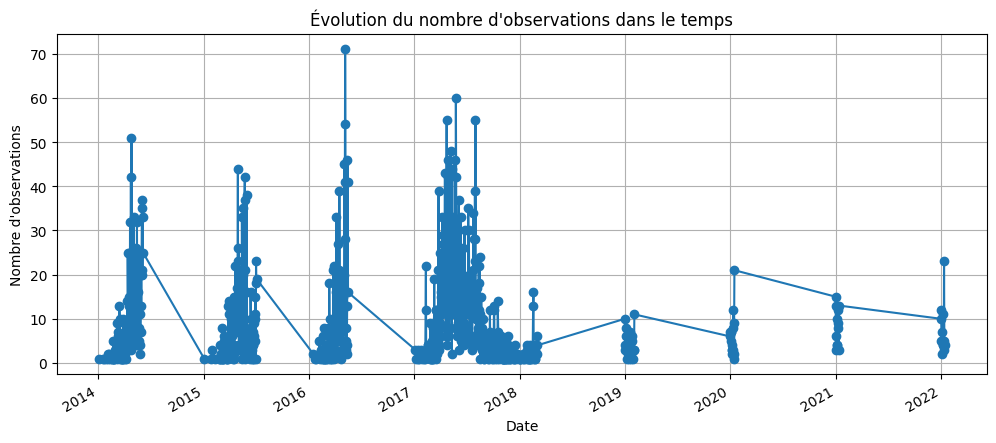

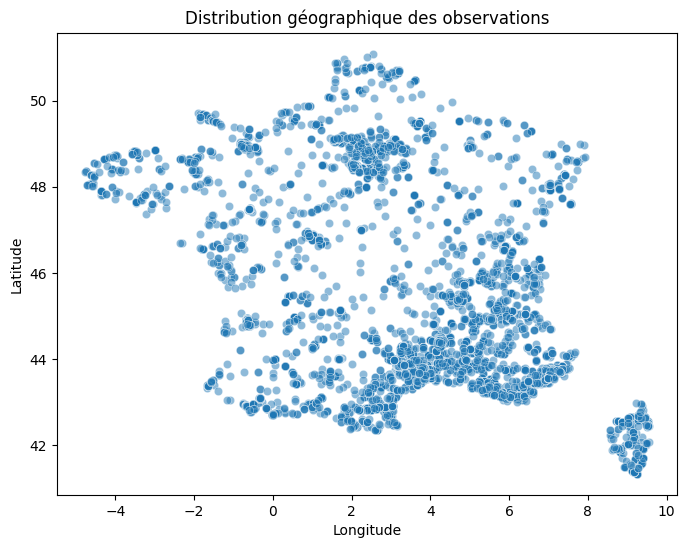

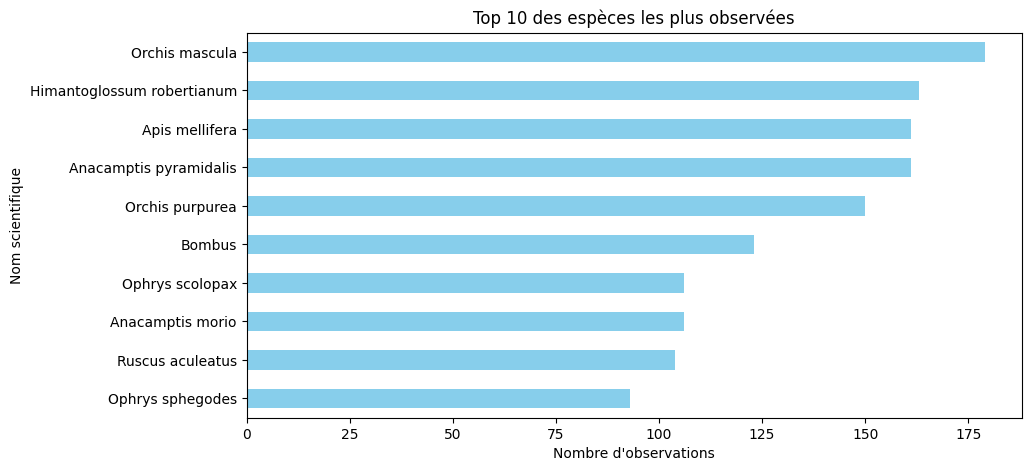

✅ Analyse terminée !


In [17]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 📂 Charger les données depuis le fichier JSON
EXTRACTED_FILE = "extracted_data.json"

if not os.path.exists(EXTRACTED_FILE):
    print(f"❌ Le fichier {EXTRACTED_FILE} n'existe pas.")
    exit()

with open(EXTRACTED_FILE, "r", encoding="utf-8") as f:
    extracted_data = json.load(f)

# 📊 Convertir en DataFrame Pandas
df = pd.DataFrame(extracted_data)

# 🔹 Vérifier la structure des données
print("🔍 Aperçu des premières lignes :")
print(df.head())

print("\n📊 Informations générales sur les données :")
print(df.info())

print("\n🔍 Nombre de valeurs manquantes par colonne :")
print(df.isnull().sum())

# 🔹 Statistiques descriptives pour les colonnes numériques
print("\n📈 Statistiques descriptives :")
print(df.describe())

# 🔹 Compter les observations par taxon
print("\n🦠 Répartition des espèces observées :")
print(df["Scientific Name"].value_counts().head(10))  # Top 10 des espèces

# 🔹 Compter les observations par utilisateur
print("\n👤 Top 10 des utilisateurs ayant le plus d'observations :")
print(df["User"].value_counts().head(10))

# 🔹 Compter les observations par qualité
print("\n🔍 Qualité des observations :")
print(df["Quality Grade"].value_counts())

# 🔹 Vérifier les doublons
duplicates = df[df.duplicated(subset=["ID"], keep=False)]
print(f"\n⚠️ Nombre de doublons dans les observations : {len(duplicates)}")

# 🔹 Vérifier les valeurs aberrantes des coordonnées
invalid_locations = df[(df["Latitude"] < -90) | (df["Latitude"] > 90) | (df["Longitude"] < -180) | (df["Longitude"] > 180)]
print(f"\n⚠️ Nombre d'observations avec des coordonnées invalides : {len(invalid_locations)}")

# 📅 🔹 Analyser la répartition des observations par date
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"])  # Supprimer les lignes où la date est invalide

plt.figure(figsize=(12, 5))
df["Date"].value_counts().sort_index().plot(kind="line", marker="o")
plt.title("Évolution du nombre d'observations dans le temps")
plt.xlabel("Date")
plt.ylabel("Nombre d'observations")
plt.grid()
plt.show()

# 🌍 🔹 Visualisation de la répartition géographique des observations
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df["Longitude"], y=df["Latitude"], alpha=0.5)
plt.title("Distribution géographique des observations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# 🦠 🔹 Visualisation des espèces les plus observées
plt.figure(figsize=(10, 5))
df["Scientific Name"].value_counts().head(10).plot(kind="barh", color="skyblue")
plt.title("Top 10 des espèces les plus observées")
plt.xlabel("Nombre d'observations")
plt.ylabel("Nom scientifique")
plt.gca().invert_yaxis()
plt.show()

print("✅ Analyse terminée !")


🔍 Aperçu des premières lignes :
          ID        Scientific Name             Common Name Taxon Rank  \
0  145577998           Vespa crabro         European Hornet    species   
1  145570252         Vespa velutina    Yellow-legged Hornet    species   
2  145568840              Eumeninae  Potter and Mason Wasps  subfamily   
3  145587919  Asparagus acutifolius         Spiny Asparagus    species   
4  145571792      Galanthus nivalis         common snowdrop    species   

   Taxon ID                                     Wikipedia Link  \
0     54327       http://en.wikipedia.org/wiki/European_hornet   
1    119019          http://en.wikipedia.org/wiki/Asian_hornet   
2    119344           http://en.wikipedia.org/wiki/Potter_wasp   
3    210513  http://en.wikipedia.org/wiki/Asparagus_acutifo...   
4     51606     http://en.wikipedia.org/wiki/Galanthus_nivalis   

             User  User Observations  User Identifications  \
0  baptiste_lecoq                678                    36   
1 

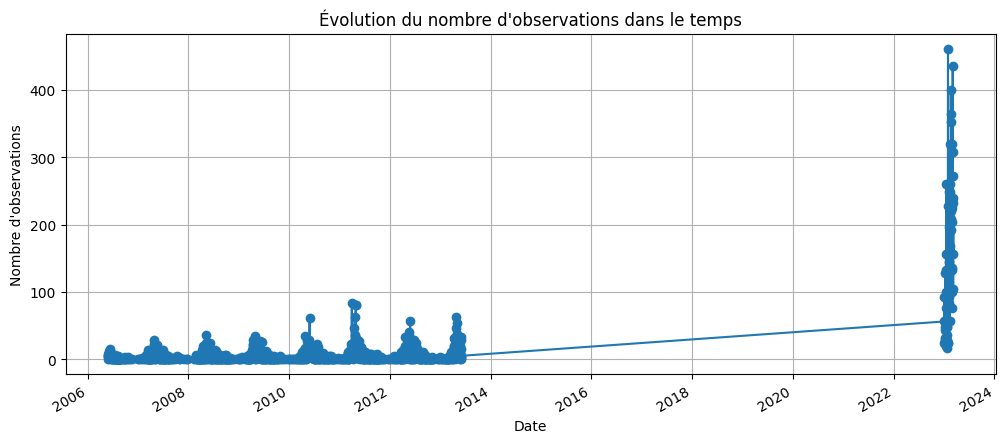

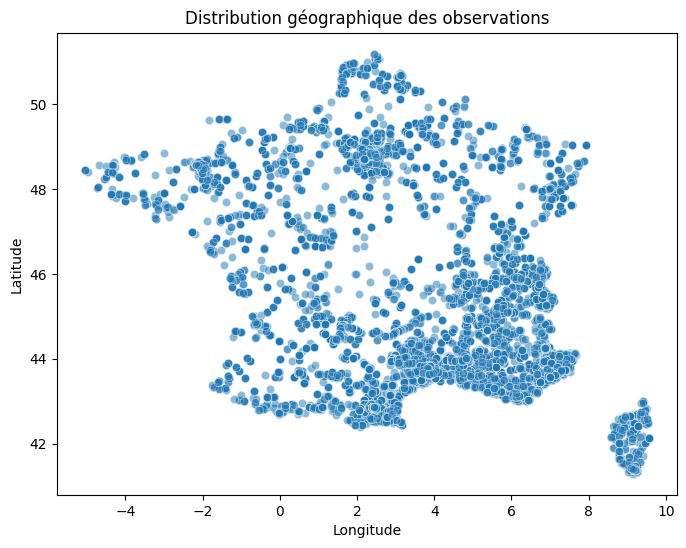

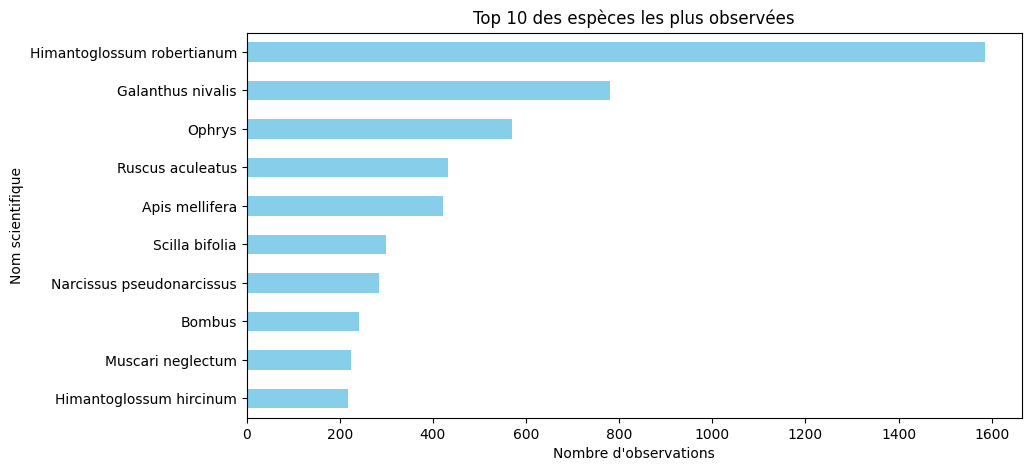

✅ Analyse terminée !


In [18]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 📂 Charger les données depuis le fichier JSON
EXTRACTED_FILE = "extracted_data_v2.json"

if not os.path.exists(EXTRACTED_FILE):
    print(f"❌ Le fichier {EXTRACTED_FILE} n'existe pas.")
    exit()

with open(EXTRACTED_FILE, "r", encoding="utf-8") as f:
    extracted_data = json.load(f)

# 📊 Convertir en DataFrame Pandas
df = pd.DataFrame(extracted_data)

# 🔹 Vérifier la structure des données
print("🔍 Aperçu des premières lignes :")
print(df.head())

print("\n📊 Informations générales sur les données :")
print(df.info())

print("\n🔍 Nombre de valeurs manquantes par colonne :")
print(df.isnull().sum())

# 🔹 Statistiques descriptives pour les colonnes numériques
print("\n📈 Statistiques descriptives :")
print(df.describe())

# 🔹 Compter les observations par taxon
print("\n🦠 Répartition des espèces observées :")
print(df["Scientific Name"].value_counts().head(10))  # Top 10 des espèces

# 🔹 Compter les observations par utilisateur
print("\n👤 Top 10 des utilisateurs ayant le plus d'observations :")
print(df["User"].value_counts().head(10))

# 🔹 Compter les observations par qualité
print("\n🔍 Qualité des observations :")
print(df["Quality Grade"].value_counts())

# 🔹 Vérifier les doublons
duplicates = df[df.duplicated(subset=["ID"], keep=False)]
print(f"\n⚠️ Nombre de doublons dans les observations : {len(duplicates)}")

# 🔹 Vérifier les valeurs aberrantes des coordonnées
invalid_locations = df[(df["Latitude"] < -90) | (df["Latitude"] > 90) | (df["Longitude"] < -180) | (df["Longitude"] > 180)]
print(f"\n⚠️ Nombre d'observations avec des coordonnées invalides : {len(invalid_locations)}")

# 📅 🔹 Analyser la répartition des observations par date
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"])  # Supprimer les lignes où la date est invalide

plt.figure(figsize=(12, 5))
df["Date"].value_counts().sort_index().plot(kind="line", marker="o")
plt.title("Évolution du nombre d'observations dans le temps")
plt.xlabel("Date")
plt.ylabel("Nombre d'observations")
plt.grid()
plt.show()

# 🌍 🔹 Visualisation de la répartition géographique des observations
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df["Longitude"], y=df["Latitude"], alpha=0.5)
plt.title("Distribution géographique des observations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# 🦠 🔹 Visualisation des espèces les plus observées
plt.figure(figsize=(10, 5))
df["Scientific Name"].value_counts().head(10).plot(kind="barh", color="skyblue")
plt.title("Top 10 des espèces les plus observées")
plt.xlabel("Nombre d'observations")
plt.ylabel("Nom scientifique")
plt.gca().invert_yaxis()
plt.show()

print("✅ Analyse terminée !")


🔍 Aperçu des premières lignes :
          ID      Scientific Name             Common Name Taxon Rank  \
0  105659355         Vespa crabro         European Hornet    species   
1  240103350       Ophrys apifera              Bee Orchid    species   
2    4896578               Bombus             Bumble Bees      genus   
3   81467404    Bombus terrestris  Buff-tailed Bumble Bee    species   
4  249304996  Megachile parietina           Black Mud Bee    species   

   Taxon ID                                    Wikipedia Link       User  \
0     54327      http://en.wikipedia.org/wiki/European_hornet     bottin   
1     83816       http://en.wikipedia.org/wiki/Ophrys_apifera   jltasset   
2     52775            http://en.wikipedia.org/wiki/Bumblebee   craigdux   
3     57516    http://en.wikipedia.org/wiki/Bombus_terrestris    moustik   
4    433919  http://en.wikipedia.org/wiki/Megachile_parietina  flienhard   

   User Observations  User Identifications  \
0              21967            

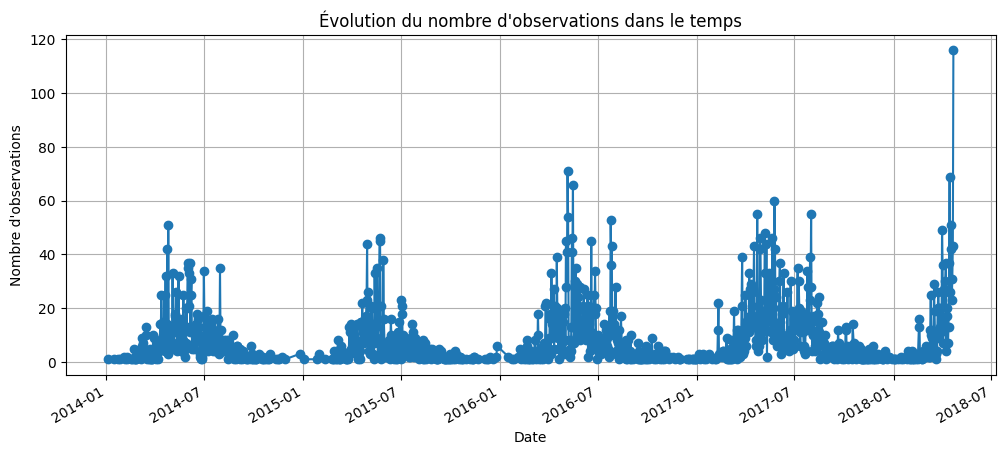

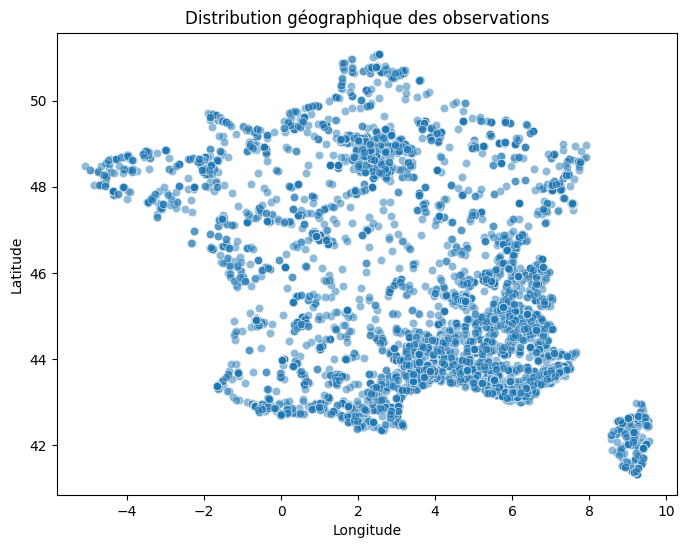

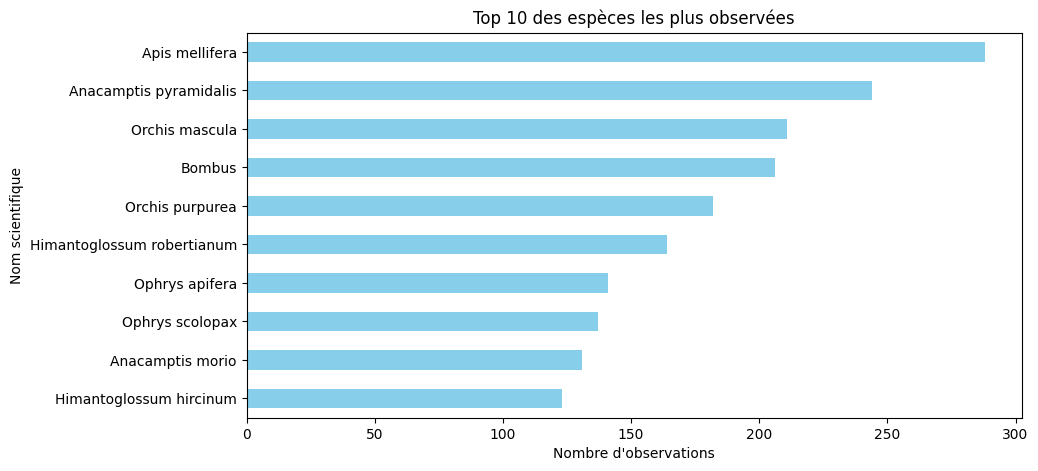

✅ Analyse terminée !


In [2]:

import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 📂 Charger les données depuis le fichier JSON
EXTRACTED_FILE = "extracted_data_3.json"

if not os.path.exists(EXTRACTED_FILE):
    print(f"❌ Le fichier {EXTRACTED_FILE} n'existe pas.")
    exit()

with open(EXTRACTED_FILE, "r", encoding="utf-8") as f:
    extracted_data = json.load(f)

# 📊 Convertir en DataFrame Pandas
df = pd.DataFrame(extracted_data)

# 🔹 Vérifier la structure des données
print("🔍 Aperçu des premières lignes :")
print(df.head())

print("\n📊 Informations générales sur les données :")
print(df.info())

print("\n🔍 Nombre de valeurs manquantes par colonne :")
print(df.isnull().sum())

# 🔹 Statistiques descriptives pour les colonnes numériques
print("\n📈 Statistiques descriptives :")
print(df.describe())

# 🔹 Compter les observations par taxon
print("\n🦠 Répartition des espèces observées :")
print(df["Scientific Name"].value_counts().head(10))  # Top 10 des espèces

# 🔹 Compter les observations par utilisateur
print("\n👤 Top 10 des utilisateurs ayant le plus d'observations :")
print(df["User"].value_counts().head(10))

# 🔹 Compter les observations par qualité
print("\n🔍 Qualité des observations :")
print(df["Quality Grade"].value_counts())

# 🔹 Vérifier les doublons
duplicates = df[df.duplicated(subset=["ID"], keep=False)]
print(f"\n⚠️ Nombre de doublons dans les observations : {len(duplicates)}")

# 🔹 Vérifier les valeurs aberrantes des coordonnées
invalid_locations = df[(df["Latitude"] < -90) | (df["Latitude"] > 90) | (df["Longitude"] < -180) | (df["Longitude"] > 180)]
print(f"\n⚠️ Nombre d'observations avec des coordonnées invalides : {len(invalid_locations)}")

# 📅 🔹 Analyser la répartition des observations par date
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"])  # Supprimer les lignes où la date est invalide

plt.figure(figsize=(12, 5))
df["Date"].value_counts().sort_index().plot(kind="line", marker="o")
plt.title("Évolution du nombre d'observations dans le temps")
plt.xlabel("Date")
plt.ylabel("Nombre d'observations")
plt.grid()
plt.show()

# 🌍 🔹 Visualisation de la répartition géographique des observations
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df["Longitude"], y=df["Latitude"], alpha=0.5)
plt.title("Distribution géographique des observations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# 🦠 🔹 Visualisation des espèces les plus observées
plt.figure(figsize=(10, 5))
df["Scientific Name"].value_counts().head(10).plot(kind="barh", color="skyblue")
plt.title("Top 10 des espèces les plus observées")
plt.xlabel("Nombre d'observations")
plt.ylabel("Nom scientifique")
plt.gca().invert_yaxis()
plt.show()

print("✅ Analyse terminée !")


In [15]:
import polars as pl
import json
import os

# 📂 Liste des fichiers JSON
json_files = [
    "extracted_data_2014_2018.json",
    "extracted_data_2020_2023.json",
    "extracted_data_v1_pre_completed_2014_2022.json",
    "extracted_data_v2.json",
    "extracted_data.json",
    "extracted_data_2023_2025.json"
]

def load_json_file(file):
    """Charge un fichier JSON en DataFrame Polars."""
    if not os.path.exists(file):
        print(f"⚠️ Skipping {file}: File not found.")
        return None

    try:
        with open(file, "r", encoding="utf-8") as f:
            data = json.load(f)  # 📌 Charger tout le fichier JSON
            if isinstance(data, dict) and "data" in data:  # Si le JSON contient une clé "data"
                data = data["data"]
            if not isinstance(data, list):  # Vérifier si on a bien une liste d'objets
                print(f"⚠️ Unexpected format in {file}, skipping.")
                return None
            return pl.DataFrame(data, strict=False)  # Désactiver strict pour accepter les types variés
    except json.JSONDecodeError as e:
        print(f"⚠️ Error loading {file}: {e}")
        return None

# Charger tous les fichiers JSON en DataFrames
dataframes = [load_json_file(file) for file in json_files]
dataframes = [df for df in dataframes if df is not None]

# 📌 Fusionner tous les DataFrames
if dataframes:
    merged_df = pl.concat(dataframes, how="vertical")

    # 🔍 Suppression des doublons
    # unique_df = merged_df.unique(keep="first")

    print(f"📊 Merged {len(merged_df)} observations, {len(unique_df)} unique observations remain after deduplication.")

    # 💾 Sauvegarder les données
    merged_df.write_json("merged_extract.json")
    print("✅ Cleaned data saved to 'merged_observations.json'.")

    # Afficher un aperçu des colonnes
    print("🔍 Aperçu des colonnes :", merged_df.columns)
    print(merged_df.head())

else:
    print("❌ No data loaded from JSON files.")


📊 Merged 71766 observations, 33376 unique observations remain after deduplication.
✅ Cleaned data saved to 'merged_observations.json'.
🔍 Aperçu des colonnes : ['ID', 'Scientific Name', 'Common Name', 'Taxon Rank', 'Taxon ID', 'Wikipedia Link', 'User', 'User Observations', 'User Identifications', 'User Icon', 'Date', 'Time Zone', 'Latitude', 'Longitude', 'Place', 'Positional Accuracy', 'Public Accuracy', 'Geoprivacy', 'Quality Grade', 'Identifications Count', 'Agreements', 'Disagreements', 'Image', 'Annotations', 'Comments Count', 'Tags', 'Votes', 'UUID', 'Description', 'Observation Link']
shape: (5, 30)
┌───────────┬────────────┬────────────┬────────────┬───┬───────┬───────────┬───────────┬───────────┐
│ ID        ┆ Scientific ┆ Common     ┆ Taxon Rank ┆ … ┆ Votes ┆ UUID      ┆ Descripti ┆ Observati │
│ ---       ┆ Name       ┆ Name       ┆ ---        ┆   ┆ ---   ┆ ---       ┆ on        ┆ on Link   │
│ i64       ┆ ---        ┆ ---        ┆ str        ┆   ┆ i64   ┆ str       ┆ ---      

#### Explore all merges

🔍 Aperçu des premières lignes :
          ID      Scientific Name             Common Name Taxon Rank  \
0  105659355         Vespa crabro         European Hornet    species   
1  240103350       Ophrys apifera              Bee Orchid    species   
2    4896578               Bombus             Bumble Bees      genus   
3   81467404    Bombus terrestris  Buff-tailed Bumble Bee    species   
4  249304996  Megachile parietina           Black Mud Bee    species   

   Taxon ID                                    Wikipedia Link       User  \
0     54327      http://en.wikipedia.org/wiki/European_hornet     bottin   
1     83816       http://en.wikipedia.org/wiki/Ophrys_apifera   jltasset   
2     52775            http://en.wikipedia.org/wiki/Bumblebee   craigdux   
3     57516    http://en.wikipedia.org/wiki/Bombus_terrestris    moustik   
4    433919  http://en.wikipedia.org/wiki/Megachile_parietina  flienhard   

   User Observations  User Identifications  \
0              21967            

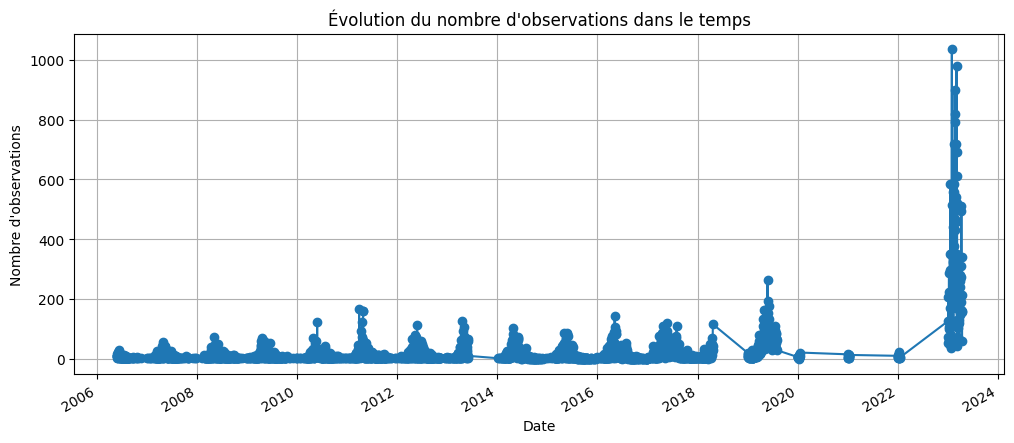

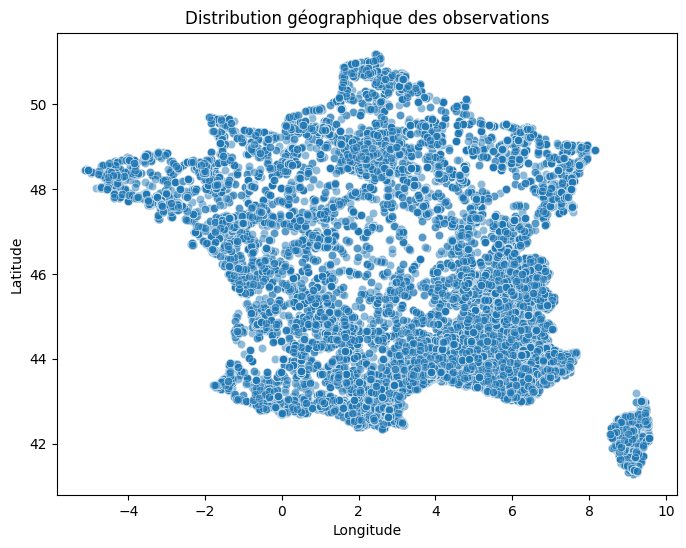

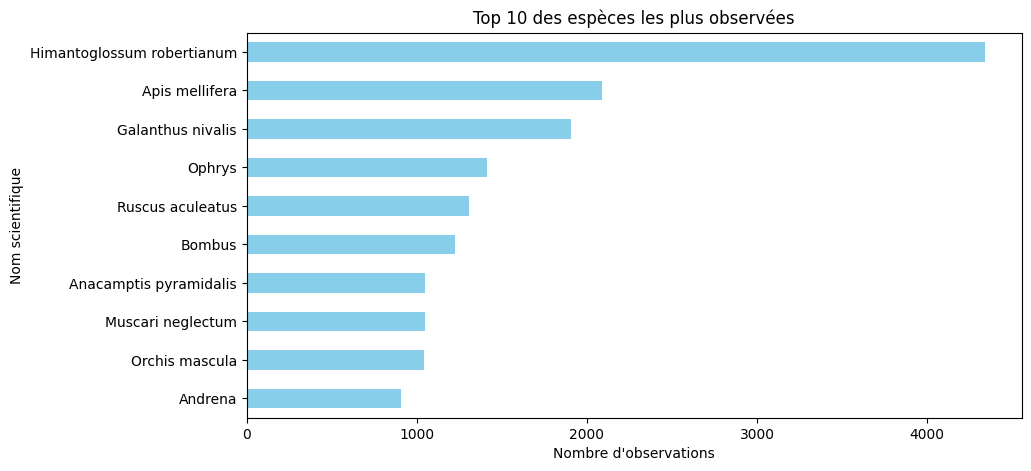

✅ Analyse terminée !


In [26]:

import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 📂 Charger les données depuis le fichier JSON
EXTRACTED_FILE = "merged_extract.json"

if not os.path.exists(EXTRACTED_FILE):
    print(f"❌ Le fichier {EXTRACTED_FILE} n'existe pas.")
    exit()

with open(EXTRACTED_FILE, "r", encoding="utf-8") as f:
    extracted_data = json.load(f)

# 📊 Convertir en DataFrame Pandas
df = pd.DataFrame(extracted_data)

# 🔹 Vérifier la structure des données
print("🔍 Aperçu des premières lignes :")
print(df.head())

print("\n📊 Informations générales sur les données :")
print(df.info())

print("\n🔍 Nombre de valeurs manquantes par colonne :")
print(df.isnull().sum())

# 🔹 Statistiques descriptives pour les colonnes numériques
print("\n📈 Statistiques descriptives :")
print(df.describe())

# 🔹 Compter les observations par taxon
print("\n🦠 Répartition des espèces observées :")
print(df["Scientific Name"].value_counts().head(10))  # Top 10 des espèces

# 🔹 Compter les observations par utilisateur
print("\n👤 Top 10 des utilisateurs ayant le plus d'observations :")
print(df["User"].value_counts().head(10))

# 🔹 Compter les observations par qualité
print("\n🔍 Qualité des observations :")
print(df["Quality Grade"].value_counts())

# 🔹 Vérifier les doublons
duplicates = df[df.duplicated(subset=["ID"], keep=False)]
print(f"\n⚠️ Nombre de doublons dans les observations : {len(duplicates)}")

# 🔹 Vérifier les valeurs aberrantes des coordonnées
invalid_locations = df[(df["Latitude"] < -90) | (df["Latitude"] > 90) | (df["Longitude"] < -180) | (df["Longitude"] > 180)]
print(f"\n⚠️ Nombre d'observations avec des coordonnées invalides : {len(invalid_locations)}")

# 📅 🔹 Analyser la répartition des observations par date
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"])  # Supprimer les lignes où la date est invalide
print(f"\n📅 Période des observations : {df['Date'].min().strftime('%Y-%m-%d')} à {df['Date'].max().strftime('%Y-%m-%d')}")
# 📌 Obtenir la période des observations
date_min = df["Date"].min().strftime('%Y-%m-%d')
date_max = df["Date"].max().strftime('%Y-%m-%d')
print(f"\n📅 Période des observations : {date_min} à {date_max}")

# 📌 Nombre d'années uniques couvertes
unique_years = df["Date"].dt.year.nunique()
print(f"📆 Nombre d'années uniques couvertes : {unique_years}")

# 📌 Nombre d'observations par année unique
observations_per_year = df["Date"].dt.year.value_counts().sort_index()
print("\n📊 Nombre d'observations par année :")
print(observations_per_year)
plt.figure(figsize=(12, 5))
df["Date"].value_counts().sort_index().plot(kind="line", marker="o")
plt.title("Évolution du nombre d'observations dans le temps")
plt.xlabel("Date")
plt.ylabel("Nombre d'observations")
plt.grid()
plt.show()

# 🌍 🔹 Visualisation de la répartition géographique des observations
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df["Longitude"], y=df["Latitude"], alpha=0.5)
plt.title("Distribution géographique des observations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# 🦠 🔹 Visualisation des espèces les plus observées
plt.figure(figsize=(10, 5))
df["Scientific Name"].value_counts().head(10).plot(kind="barh", color="skyblue")
plt.title("Top 10 des espèces les plus observées")
plt.xlabel("Nombre d'observations")
plt.ylabel("Nom scientifique")
plt.gca().invert_yaxis()
plt.show()

print("✅ Analyse terminée !")


In [27]:
# 🔹 Convertir toutes les colonnes contenant des listes en chaînes de caractères
for col in df.columns:
    if df[col].apply(lambda x: isinstance(x, list)).any():  # Vérifier si une colonne contient des listes
        df[col] = df[col].astype(str)  # Convertir en chaîne

# 🚀 Maintenant, on peut supprimer les doublons sans erreur
df = df.drop_duplicates(keep="first")  # Supprime les doublons en gardant la première occurrence

print(f"✅ Nombre de doublons supprimés : {len(df)}")


✅ Nombre de doublons supprimés : 42051


In [28]:

print(f"📊 Nombre total d'observations : {len(df)}")
print(f"🧑‍🤝‍🧑 Nombre d'utilisateurs uniques : {df['User'].nunique()}")
print(f"🦠 Nombre d'espèces uniques observées : {df['Scientific Name'].nunique()}")
print(f"📍 Nombre de lieux uniques : {df['Place'].nunique()}")
print(f"📅 Période couverte : {df['Date'].min().strftime('%Y-%m-%d')} à {df['Date'].max().strftime('%Y-%m-%d')}")


📊 Nombre total d'observations : 42051
🧑‍🤝‍🧑 Nombre d'utilisateurs uniques : 5882
🦠 Nombre d'espèces uniques observées : 1149
📍 Nombre de lieux uniques : 12955
📅 Période couverte : 2006-05-28 à 2023-04-14


c:\Users\Yann\Desktop\DEV\stages\Abeille\daen-analytics\abeilles\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


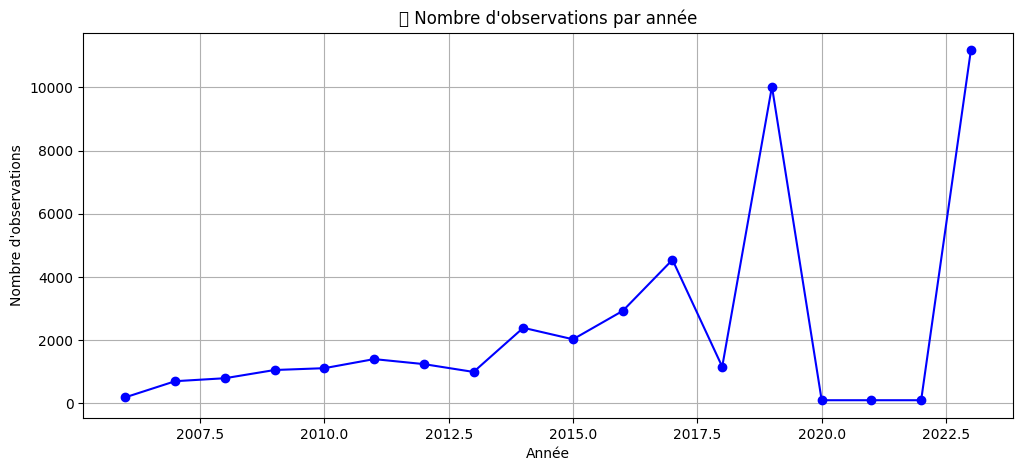

In [29]:
plt.figure(figsize=(12, 5))
df["Date"].dt.year.value_counts().sort_index().plot(kind="line", marker="o", color="blue")
plt.title("📅 Nombre d'observations par année")
plt.xlabel("Année")
plt.ylabel("Nombre d'observations")
plt.grid()
plt.show()


c:\Users\Yann\Desktop\DEV\stages\Abeille\daen-analytics\abeilles\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


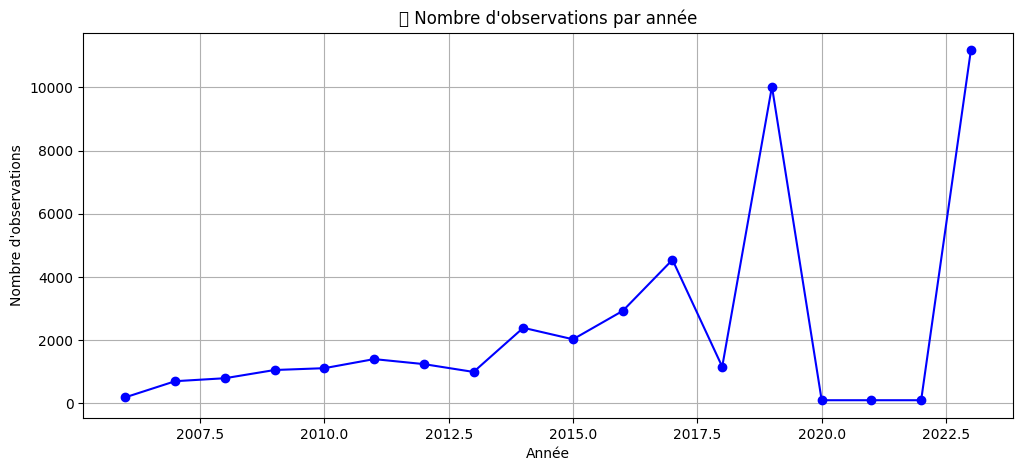

In [30]:
plt.figure(figsize=(12, 5))
df["Date"].dt.year.value_counts().sort_index().plot(kind="line", marker="o", color="blue")
plt.title("📅 Nombre d'observations par année")
plt.xlabel("Année")
plt.ylabel("Nombre d'observations")
plt.grid()
plt.show()


c:\Users\Yann\Desktop\DEV\stages\Abeille\daen-analytics\abeilles\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


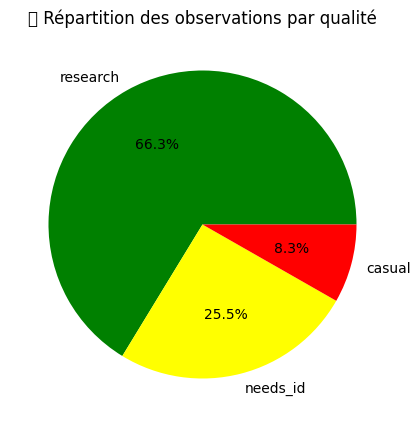

In [31]:
plt.figure(figsize=(6, 5))
df["Quality Grade"].value_counts().plot(kind="pie", autopct="%1.1f%%", colors=["green", "yellow", "red"])
plt.title("🔍 Répartition des observations par qualité")
plt.ylabel("") 
plt.show()


c:\Users\Yann\Desktop\DEV\stages\Abeille\daen-analytics\abeilles\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128198 (\N{TEAR-OFF CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


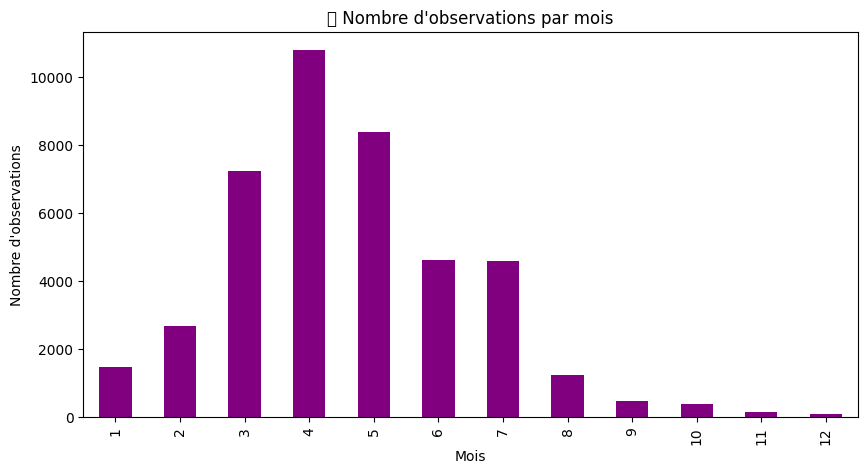

In [32]:
plt.figure(figsize=(10, 5))
df["Month"] = df["Date"].dt.month
df["Month"].value_counts().sort_index().plot(kind="bar", color="purple")
plt.title("📆 Nombre d'observations par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre d'observations")
plt.show()


In [34]:

!pip install geopandas folium

  Using cached geopandas-1.0.1-py3-none-any.whl.metadata (2.2 kB)
  Using cached folium-0.19.4-py2.py3-none-any.whl.metadata (3.8 kB)
  Using cached pyogrio-0.10.0-cp312-cp312-win_amd64.whl.metadata (5.6 kB)
  Using cached pyproj-3.7.0-cp312-cp312-win_amd64.whl.metadata (31 kB)
  Using cached branca-0.8.1-py3-none-any.whl.metadata (1.5 kB)
  Using cached xyzservices-2025.1.0-py3-none-any.whl.metadata (4.3 kB)
Using cached geopandas-1.0.1-py3-none-any.whl (323 kB)
Using cached folium-0.19.4-py2.py3-none-any.whl (110 kB)
Using cached branca-0.8.1-py3-none-any.whl (26 kB)
Using cached pyogrio-0.10.0-cp312-cp312-win_amd64.whl (16.2 MB)
Using cached pyproj-3.7.0-cp312-cp312-win_amd64.whl (6.2 MB)
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.4 MB 3.4 MB/s eta 0:00:01
   ------------------------------------ --- 1.3/1.4 MB 3.7 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 3.0 MB/s eta 0:00:00
Us

In [35]:
import geopandas as gpd
import folium
from folium.plugins import HeatMap

# Créer une carte centrée sur la France (ajuste les coordonnées si nécessaire)
m = folium.Map(location=[46.603354, 1.888334], zoom_start=5)

# Ajouter les points sous forme de heatmap
heat_data = df[['Latitude', 'Longitude']].dropna().values.tolist()
HeatMap(heat_data, radius=8, blur=4).add_to(m)

# Afficher la carte
m


c:\Users\Yann\Desktop\DEV\stages\Abeille\daen-analytics\abeilles\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128198 (\N{TEAR-OFF CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


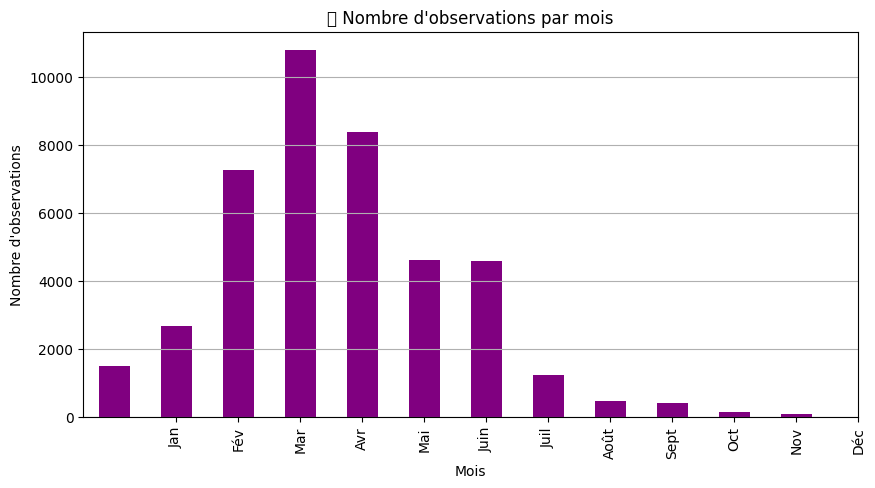

In [36]:
df["Month"] = df["Date"].dt.month

plt.figure(figsize=(10, 5))
df["Month"].value_counts().sort_index().plot(kind="bar", color="purple")
plt.title("📆 Nombre d'observations par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre d'observations")
plt.xticks(range(1, 13), ["Jan", "Fév", "Mar", "Avr", "Mai", "Juin", "Juil", "Août", "Sept", "Oct", "Nov", "Déc"])
plt.grid(axis="y")
plt.show()


c:\Users\Yann\Desktop\DEV\stages\Abeille\daen-analytics\abeilles\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129440 (\N{MICROBE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


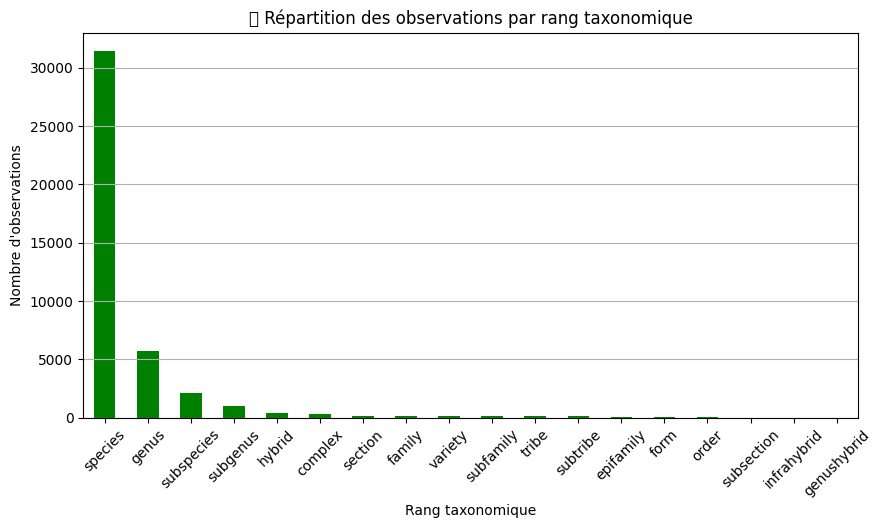

In [37]:
plt.figure(figsize=(10, 5))
df["Taxon Rank"].value_counts().plot(kind="bar", color="green")
plt.title("🦠 Répartition des observations par rang taxonomique")
plt.xlabel("Rang taxonomique")
plt.ylabel("Nombre d'observations")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()


c:\Users\Yann\Desktop\DEV\stages\Abeille\daen-analytics\abeilles\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


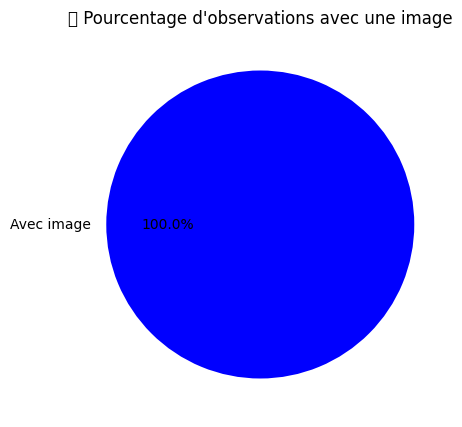

In [38]:
df["Has Image"] = df["Image"].notna()  # Vérifier la présence d'une image

plt.figure(figsize=(6, 5))
df["Has Image"].value_counts().plot(kind="pie", autopct="%1.1f%%", labels=["Avec image", "Sans image"], colors=["blue", "gray"])
plt.title("📸 Pourcentage d'observations avec une image")
plt.ylabel("")  # Pas besoin de label Y pour un pie chart
plt.show()


c:\Users\Yann\Desktop\DEV\stages\Abeille\daen-analytics\abeilles\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


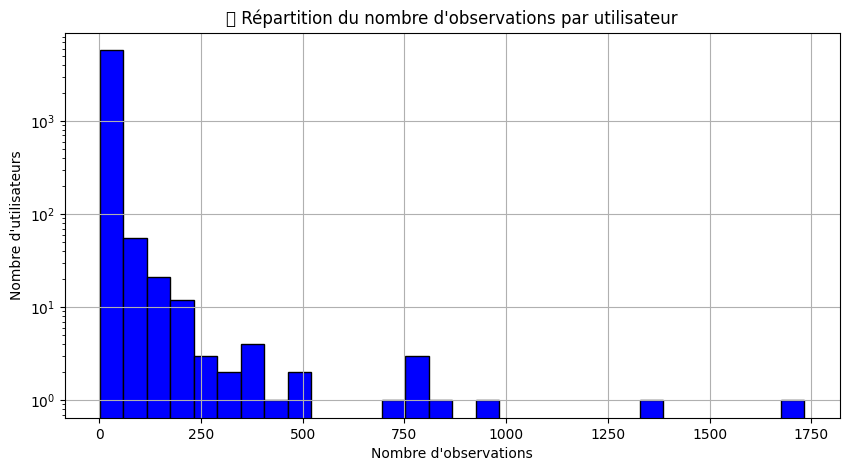

In [39]:
plt.figure(figsize=(10, 5))
df["User"].value_counts().plot(kind="hist", bins=30, color="blue", edgecolor="black")
plt.title("📊 Répartition du nombre d'observations par utilisateur")
plt.xlabel("Nombre d'observations")
plt.ylabel("Nombre d'utilisateurs")
plt.yscale("log")  # Logarithmique pour mieux voir la répartition
plt.grid()
plt.show()


In [42]:
!pip install wordcloud

c:\Users\Yann\Desktop\DEV\stages\Abeille\daen-analytics\abeilles\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


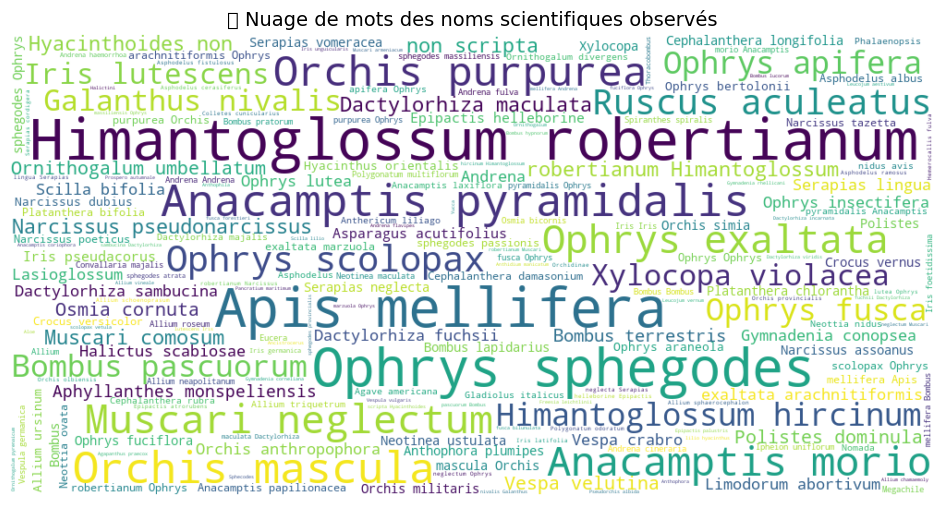

In [43]:
# Importer les bibliothèques nécessaires
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Vérifier que la colonne existe et ne contient pas de valeurs nulles
if "Scientific Name" in df.columns:
    # Concaténer tous les noms scientifiques en une seule chaîne de caractères
    scientific_names_text = " ".join(df["Scientific Name"].dropna())

    # Générer le nuage de mots
    wordcloud = WordCloud(width=1000, height=500, background_color="white", colormap="viridis").generate(scientific_names_text)

    # Afficher le nuage de mots
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("🌿 Nuage de mots des noms scientifiques observés", fontsize=14)
    plt.show()
else:
    print("❌ La colonne 'Scientific Name' n'existe pas dans le DataFrame.")


#### Espèces observées

🐝 Espèces d'abeilles :
- Apis mellifera (Abeille domestique)
- Bombus pascuorum (Bourdon des champs)
- Bombus terrestris (Bourdon terrestre)
- Osmia cornuta (Osmie cornue)
- Xylocopa violacea (Abeille charpentière)

🦟 Espèces de guêpes :
- Vespa velutina (Frelon asiatique)
- Polistes dominula (Guêpe poliste européenne)

c:\Users\Yann\Desktop\DEV\stages\Abeille\daen-analytics\abeilles\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


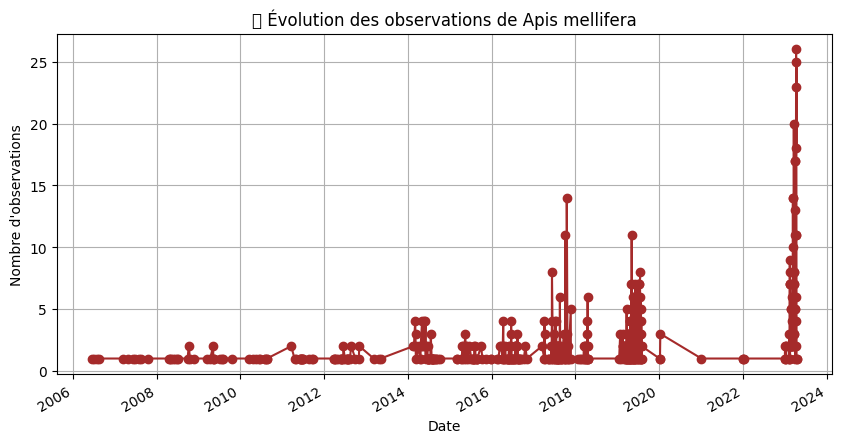

In [40]:
species = "Apis mellifera"  # Nom scientifique
df_species = df[df["Scientific Name"] == species]
df_species["Date"].value_counts().sort_index().plot(kind="line", marker="o", figsize=(10, 5), color="brown")
plt.title(f"📈 Évolution des observations de {species}")
plt.xlabel("Date")
plt.ylabel("Nombre d'observations")
plt.grid()
plt.show()



📊 Proportions des espèces observées :
     Scientific Name  Proportion (%)
0     Apis mellifera        3.003496
1   Bombus pascuorum        1.072507
2  Xylocopa violacea        0.989275
3      Osmia cornuta        0.827567
4  Polistes dominula        0.815676
5     Vespa velutina        0.722932
6  Bombus terrestris        0.718176


c:\Users\Yann\Desktop\DEV\stages\Abeille\daen-analytics\abeilles\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128029 (\N{HONEYBEE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


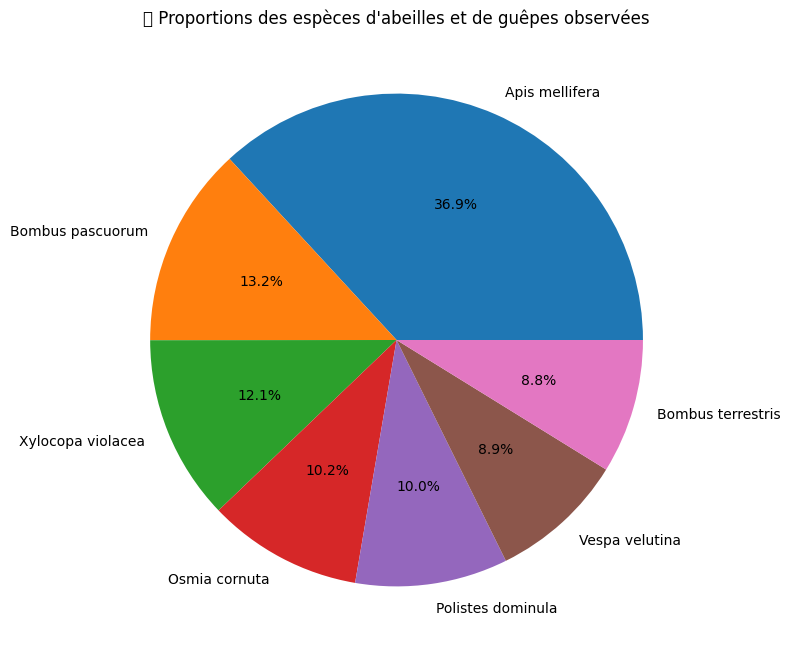

c:\Users\Yann\Desktop\DEV\stages\Abeille\daen-analytics\abeilles\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


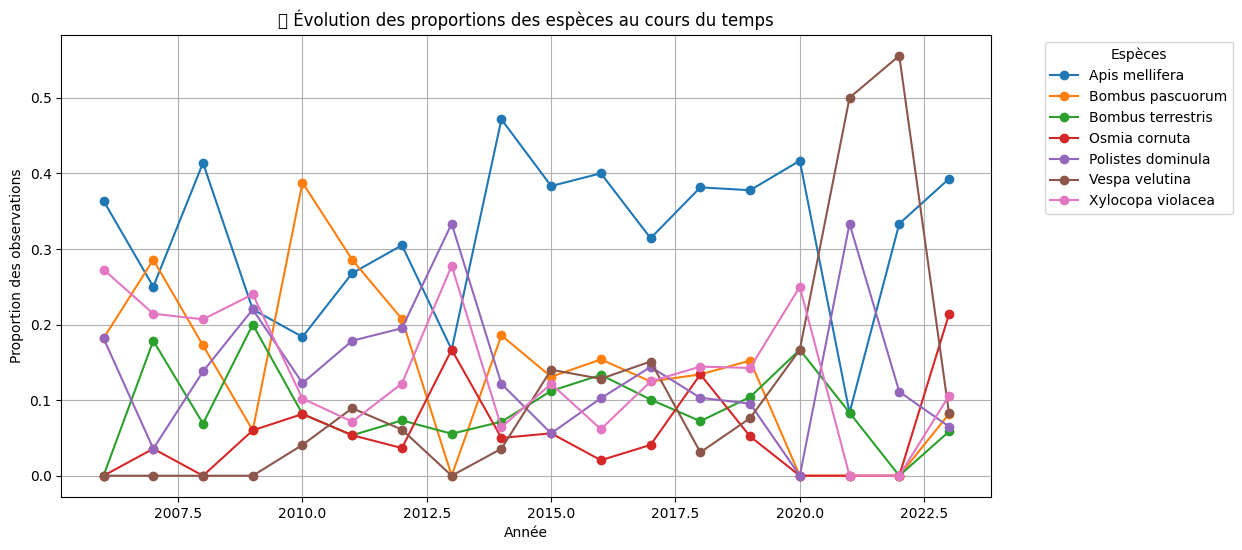

c:\Users\Yann\Desktop\DEV\stages\Abeille\daen-analytics\abeilles\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


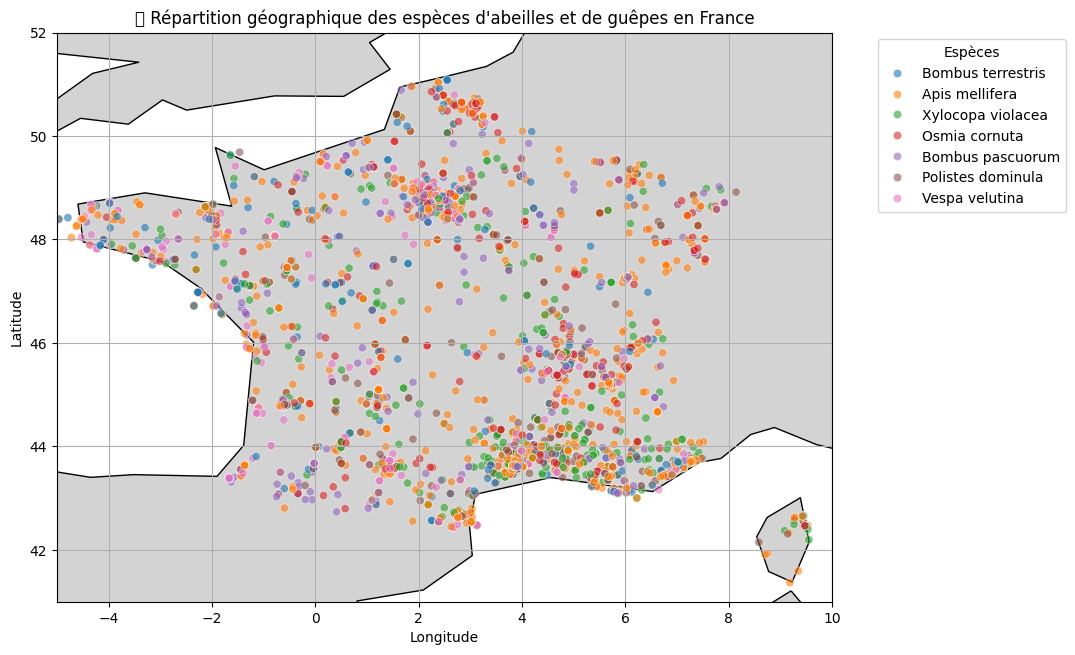

In [49]:
# Liste des espèces d'abeilles et de guêpes à analyser
species_list = [
    "Apis mellifera",  # Abeille domestique
    "Bombus pascuorum",  # Bourdon des champs
    "Bombus terrestris",  # Bourdon terrestre
    "Osmia cornuta",  # Osmie cornue
    "Xylocopa violacea",  # Abeille charpentière
    "Vespa velutina",  # Frelon asiatique
    "Polistes dominula"  # Guêpe poliste européenne
]

# 1️⃣ **Calculer et afficher les proportions de chaque espèce**
filtered_df = df[df["Scientific Name"].isin(species_list)]

# Compter les occurrences et calculer les proportions
species_counts = filtered_df["Scientific Name"].value_counts()
species_proportions = (species_counts / len(df)) * 100

# Afficher les proportions sous forme de tableau
df_proportions = pd.DataFrame({
    "Scientific Name": species_proportions.index,
    "Proportion (%)": species_proportions.values
})
print("\n📊 Proportions des espèces observées :")
print(df_proportions)

# 🔹 **Afficher les proportions sous forme de diagramme en camembert**
plt.figure(figsize=(8, 8))
species_counts.plot(kind="pie", autopct="%1.1f%%", colors=sns.color_palette("tab10"))
plt.title("🐝 Proportions des espèces d'abeilles et de guêpes observées")
plt.ylabel("")  # Enlever l'étiquette inutile
plt.show()

# 2️⃣ **Évolution des proportions de chaque espèce au cours du temps**
df_time = filtered_df.copy()
df_time["Year"] = df_time["Date"].dt.year  # Extraire l'année

# Compter les observations par espèce et par année
species_over_time = df_time.groupby(["Year", "Scientific Name"]).size().unstack(fill_value=0)

# Afficher les proportions au cours du temps
plt.figure(figsize=(12, 6))
species_over_time.div(species_over_time.sum(axis=1), axis=0).plot(kind="line", marker="o", ax=plt.gca())
plt.title("📈 Évolution des proportions des espèces au cours du temps")
plt.xlabel("Année")
plt.ylabel("Proportion des observations")
plt.legend(title="Espèces", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid()
plt.show()

# 3️⃣ **Afficher la répartition géographique des observations avec les proportions**
# Charger les données géographiques
import geodatasets
# Définir les limites géographiques pour zoomer sur la France
france_bounds = {
    "xmin": -5.0,  # Longitude minimale (Ouest)
    "xmax": 10.0,  # Longitude maximale (Est)
    "ymin": 41.0,  # Latitude minimale (Sud)
    "ymax": 52.0   # Latitude maximale (Nord)
}
# Créer un GeoDataFrame avec les observations filtrées
gdf = gpd.GeoDataFrame(filtered_df, geometry=gpd.points_from_xy(filtered_df.Longitude, filtered_df.Latitude))

# Tracer la carte avec zoom sur la France
fig, ax = plt.subplots(figsize=(10, 8))
world.plot(ax=ax, color="lightgray", edgecolor="black")

# Ajouter les points des observations, colorés par espèce
sns.scatterplot(x=gdf.geometry.x, y=gdf.geometry.y, hue=gdf["Scientific Name"], alpha=0.6, palette="tab10", ax=ax)

# Définir les limites pour zoomer sur la France
ax.set_xlim(france_bounds["xmin"], france_bounds["xmax"])
ax.set_ylim(france_bounds["ymin"], france_bounds["ymax"])

# Ajouter les labels et le titre
plt.title("📍 Répartition géographique des espèces d'abeilles et de guêpes en France")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Espèces", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid()

# Afficher la carte
plt.show()

In [47]:
!pip install geodatasets


## MERGE 2023-2025 & Analyze


In [14]:
import polars as pl
import json
import glob

# 📂 Automatically Detect JSON Files
json_files = glob.glob("extracted_data_*.json")  # Matches all extracted JSON files

# 🔄 Load JSON files into Polars DataFrames
dataframes = []
for file in json_files:
    try:
        with open(file, "r", encoding="utf-8") as f:
            data = json.load(f)
            if data:  # Ensure it's not empty
                df = pl.DataFrame(data)
                dataframes.append(df)
                print(f"✅ Loaded {len(df)} observations from {file}.")
    except (json.JSONDecodeError, FileNotFoundError) as e:
        print(f"⚠️ Skipping {file}: {e}")

# 📌 Merge all DataFrames
if dataframes:
    merged_df = pl.concat(dataframes, how="vertical_relaxed")  # Faster concatenation


    # 💾 Save the cleaned data
    merged_df.write_json("merged_extracted_data.json", pretty=True)
    print("✅ Cleaned data saved to 'merged_extracted_data.json'.")

else:
    print("❌ No valid data found for merging.")


✅ Loaded 20000 observations from extracted_data_2023_2025.json.
✅ Loaded 10000 observations from extracted_data_2023_2025_v2.json.


KeyboardInterrupt: 

In [28]:
import polars as pl
import json
import os

# 📂 List of JSON files to merge
json_files = [
    "extracted_data_2023_2025_v2.json",
    "extracted_data_2023_2025_v3.json",
    "extracted_data_2023_2025_v4.json",
    "extracted_data_20245_2025_v5.json",
    "extracted_data_fev_2025_v.json"
]

# 🔄 Load JSON files into Polars DataFrames
dataframes = []
all_columns = set()  # Collect all unique column names
column_types = {}  # Store expected column types
missing_columns_log = {}  # Log missing columns per dataset

for file in json_files:
    try:
        with open(file, "r", encoding="utf-8") as f:
            data = json.load(f)
            if data:  # Ensure file is not empty
                df = pl.DataFrame(data)
                all_columns.update(df.columns)  # Collect unique column names

                # Store column types and check for mismatches
                for col in df.columns:
                    dtype = df[col].dtype

                    if col in column_types and column_types[col] != dtype:
                        print(f"⚠️ Type mismatch in '{col}': Expected {column_types[col]}, but found {dtype}")
                        # Use Utf8 for strings, keep numbers as they are
                        column_types[col] = pl.Utf8 if "String" in str(dtype) else column_types[col]
                    else:
                        column_types[col] = dtype

                dataframes.append(df)
                print(f"✅ Loaded {len(df)} observations from {file}.")

    except (json.JSONDecodeError, FileNotFoundError) as e:
        print(f"⚠️ Skipping {file}: {e}")

# Step 2️⃣: Standardize DataFrames by Adding Missing Columns
all_columns = list(all_columns)  # Convert to list for consistent ordering
aligned_dataframes = []

for i, df in enumerate(dataframes):
    missing_columns = set(all_columns) - set(df.columns)
    missing_columns_log[json_files[i]] = list(missing_columns)  # Log missing columns

    if missing_columns:
        print(f"⚠️ Missing columns in {json_files[i]}: {missing_columns}")

    for col in missing_columns:
        df = df.with_columns(pl.lit(None).cast(column_types.get(col, pl.Utf8)).alias(col))  # Add missing columns

    # **Fix Type Mismatches** 
    for col in df.columns:
        col_dtype = column_types[col]

        # ✅ Convert Lists of Strings to comma-separated strings
        if isinstance(col_dtype, pl.List) and col_dtype.inner == pl.Utf8:
            df = df.with_columns(
                df[col].map_elements(lambda x: ",".join(map(str, x)) if isinstance(x, list) else str(x), return_dtype=pl.Utf8)
            )

        # ✅ Convert Lists of Integers to comma-separated strings
        elif isinstance(col_dtype, pl.List) and col_dtype.inner == pl.Int64:
            df = df.with_columns(
                df[col].map_elements(lambda x: ",".join(map(str, x)) if isinstance(x, list) else str(x), return_dtype=pl.Utf8)
            )

        # ✅ Convert List(Null) to empty lists `[]`
        elif col_dtype == pl.List(pl.Null):
            df = df.with_columns(
                df[col].map_elements(lambda x: [] if x is None else x, return_dtype=pl.List(pl.Utf8))
            )

        # ✅ Convert List(Struct({})) to JSON strings
        elif isinstance(col_dtype, pl.List) and "Struct" in str(col_dtype.inner):
            df = df.with_columns(
                df[col].map_elements(lambda x: json.dumps(x) if isinstance(x, list) else str(x), return_dtype=pl.Utf8)
            )

        # ✅ Convert everything else safely, handling errors
        else:
            try:
                if isinstance(col_dtype, pl.Int64):  # Convert Int64 to Utf8 if necessary
                    df = df.with_columns(df[col].cast(pl.Utf8))
                else:
                    df = df.with_columns(df[col].cast(col_dtype))
            except pl.exceptions.ComputeError:
                print(f"⚠️ Skipping cast for column {col} due to incompatible data types.")

    aligned_dataframes.append(df.select(all_columns))  # Reorder columns

# Step 3️⃣: Merge All DataFrames After Alignment
merged_df = pl.concat(aligned_dataframes, how="vertical")

# Step 4️⃣: Identify Columns with Null Values
null_counts = merged_df.null_count()

print("\n🔍 Columns with Null Values:")
for col in merged_df.columns:
    null_count_value = null_counts[col].item()  # Extract scalar value
    if null_count_value > 0:
        print(f"⚠️ Column '{col}' has {null_count_value} missing values.")


print(f"\n📊 Merged {len(merged_df)} observations, {len(unique_df)} unique observations remain after deduplication.")

# Step 6️⃣: Save the Cleaned DataFrame
merged_df.write_json("merged_observations.json")
print("✅ Cleaned data saved to 'merged_observations.json'.")


✅ Loaded 10000 observations from extracted_data_2023_2025_v2.json.
✅ Loaded 266162 observations from extracted_data_2023_2025_v3.json.
⚠️ Type mismatch in 'sounds': Expected List(Struct({'id': Int64})), but found List(Null)
✅ Loaded 2400 observations from extracted_data_2023_2025_v4.json.
⚠️ Type mismatch in 'tags': Expected List(String), but found List(Null)
⚠️ Type mismatch in 'sounds': Expected List(Struct({'id': Int64})), but found List(Null)
✅ Loaded 8000 observations from extracted_data_20245_2025_v5.json.
⚠️ Type mismatch in 'sounds': Expected List(Struct({'id': Int64})), but found List(Null)
⚠️ Type mismatch in 'outlinks': Expected List(Struct({})), but found List(Null)
✅ Loaded 3000 observations from extracted_data_fev_2025_v.json.

🔍 Columns with Null Values:
⚠️ Column 'place_guess' has 39 missing values.
⚠️ Column 'description' has 189021 missing values.
⚠️ Column 'geoprivacy' has 289562 missing values.
⚠️ Column 'positional_accuracy' has 75185 missing values.
⚠️ Column 'pub

In [29]:
merged_df.head()

quality_grade,project_ids,observation_photos,identifications,place_guess,faves_count,description,observed_on,place_ids,num_identification_disagreements,user,location,photos,id,taxon,tags,geoprivacy,updated_at,cached_votes_total,comments_count,created_at,geojson,uuid,observed_time_zone,annotations,obscured,identifications_count,num_identification_agreements,sounds,positional_accuracy,public_positional_accuracy,outlinks
str,str,str,str,str,str,str,str,str,str,struct[6],str,str,str,struct[9],str,null,str,str,str,str,struct[2],str,str,str,bool,str,str,str,str,str,str
"""research""","""shape: (0,) Series: '' [i64] […","""shape: (1,) Series: '' [struct…","""shape: (2,) Series: '' [struct…","""Bernos-Beaulac, Nouvelle-Aquit…","""0""","""""","""2024-08-05""","""shape: (10,) Series: '' [i64] …","""0""","{780263,""jean-yves_boutet"",""JEAN-YVES BOUTET"",""https://static.inaturalist.org/attachments/users/icons/780263/medium.jpg?1701453630"",[],""2018-03-04T02:17:03+00:00""}","""44.3583116667,-0.2910783333""","""shape: (1,) Series: '' [struct…","""234119354""","{54327,""Vespa crabro"",""species"",""European Hornet"",""http://en.wikipedia.org/wiki/European_hornet"",{55845561,""https://inaturalist-open-data.s3.amazonaws.com/photos/55845561/square.jpg"",""(c) Ryszard, some rights reserved (CC BY-NC)"",""cc-by-nc""},""Insecta"",[48460, 1, … 54327],null}","""shape: (0,) Series: '' [str] […",null,"""2024-08-06T13:23:18+02:00""","""0""","""0""","""2024-08-06T13:00:38+02:00""","{[-0.291078, 44.358312],""Point""}","""1f8e2c81-4261-4d9f-b9b1-d0471c…","""Europe/Paris""","""shape: (0,) Series: '' [struct…",false,"""1""","""1""","""shape: (0,) Series: '' [struct…","""4""","""4""","""shape: (1,) Series: '' [struct…"
"""research""","""shape: (0,) Series: '' [i64] […","""shape: (1,) Series: '' [struct…","""shape: (2,) Series: '' [struct…","""05100 Montgenèvre, France""","""0""",null,"""2024-08-05""","""shape: (17,) Series: '' [i64] …","""0""","{1530852,""lupoli_roland"",""Lupoli Roland"",""https://static.inaturalist.org/attachments/users/icons/1530852/medium.jpg?1552760903"",[],""2019-03-16T16:52:05+00:00""}","""44.9317250477,6.7214708116""","""shape: (1,) Series: '' [struct…","""234155457""","{127743,""Dolichovespula sylvestris"",""species"",""Tree Wasp"",""http://en.wikipedia.org/wiki/Dolichovespula_sylvestris"",{2034569,""https://inaturalist-open-data.s3.amazonaws.com/photos/2034569/square.jpg"",""(c) gailhampshire, some rights reserved (CC BY)"",""cc-by""},""Insecta"",[48460, 1, … 127743],null}","""shape: (0,) Series: '' [str] […",null,"""2024-08-07T03:11:13+02:00""","""0""","""0""","""2024-08-06T17:04:11+02:00""","{[6.721471, 44.931725],""Point""}","""40ec37d7-b767-436e-8d3d-e5b693…","""Europe/Paris""","""shape: (0,) Series: '' [struct…",false,"""1""","""1""","""shape: (0,) Series: '' [struct…","""5""","""5""","""shape: (1,) Series: '' [struct…"
"""needs_id""","""shape: (0,) Series: '' [i64] […","""shape: (1,) Series: '' [struct…","""shape: (1,) Series: '' [struct…","""05150 Saint-André-de-Rosans, F…","""0""",null,"""2024-08-05""","""shape: (16,) Series: '' [i64] …","""0""","{2023821,""geum"",""François-Xavier Taxil"",""https://static.inaturalist.org/attachments/users/icons/2023821/medium.jpg?1718814725"",[],""2019-07-20T11:34:23+00:00""}","""44.3611266667,5.514295""","""shape: (1,) Series: '' [struct…","""234026540""","{84640,""Polistes dominula"",""species"",""European Paper Wasp"",""http://en.wikipedia.org/wiki/Polistes_dominula"",{211116756,""https://inaturalist-open-data.s3.amazonaws.com/photos/211116756/square.jpg"",""(c) IronChris, some rights reserved (CC BY-SA)"",""cc-by-sa""},""Insecta"",[48460, 1, … 84640],null}","""shape: (0,) Series: '' [str] […",null,"""2024-08-05T23:37:02+02:00""","""0""","""0""","""2024-08-05T23:37:02+02:00""","{[5.514295, 44.361127],""Point""}","""8682151f-651e-445a-87fe-7f536b…","""Europe/Paris""","""shape: (0,) Series: '' [struct…",false,"""0""","""0""","""shape: (0,) Series: '' [struct…",null,null,"""shape: (0,) 